In [4]:
import pandas as pd
import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
import missingno as msno
import seaborn as sns
import re
from sklearn.model_selection import train_test_split, GridSearchCV
from collections import Counter
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.svm import *
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, r2_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import SMOTE
import datetime
from pathlib import Path
import pickle
import os


# **Import data**


In [7]:
print('Notebook CWD:', os.getcwd())
print('Files in CWD:', os.listdir('.'))

autos_path = Path(r'D:\mmm\mmm\2025-2026 5SAE1\AI\projet\autos.csv')
print(str(autos_path), 'exists?', autos_path.exists())
if not autos_path.exists():
    raise FileNotFoundError(f"autos.csv not found at the specified path: {autos_path}")

print('Loading file from:', autos_path)
autos = pd.read_csv(autos_path, encoding='latin1')
print('Loaded autos with shape:', autos.shape)

Notebook CWD: d:\mmm\mmm\2025-2026 5SAE1\AI\projet
Files in CWD: ['Ai_MarketPlace', 'app.py', 'autos.csv', 'documentation.txt', 'fraud_detection.ipynb', 'Internship_report.pdf', 'rf_fraud_model.pkl', 'scaler.pkl']
D:\mmm\mmm\2025-2026 5SAE1\AI\projet\autos.csv exists? True
Loading file from: D:\mmm\mmm\2025-2026 5SAE1\AI\projet\autos.csv
Loaded autos with shape: (50000, 20)
Loaded autos with shape: (50000, 20)


# **EDA**

In [8]:
autos.head()

,dateCrawled,name,seller,offerType,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,odometer,monthOfRegistration,fuelType,brand,notRepairedDamage,dateCreated,nrOfPictures,postalCode,lastSeen
0,2016-03-26 17:47:46,Peugeot_807_160_NAVTECH_ON_BOARD,privat,Angebot,"$5,000",control,bus,2004,manuell,158,andere,"150,000km",3,lpg,peugeot,nein,2016-03-26 00:00:00,0,79588,2016-04-06 06:45:54
1,2016-04-04 13:38:56,BMW_740i_4_4_Liter_HAMANN_UMBAU_Mega_Optik,privat,Angebot,"$8,500",control,limousine,1997,automatik,286,7er,"150,000km",6,benzin,bmw,nein,2016-04-04 00:00:00,0,71034,2016-04-06 14:45:08
2,2016-03-26 18:57:24,Volkswagen_Golf_1.6_United,privat,Angebot,"$8,990",test,limousine,2009,manuell,102,golf,"70,000km",7,benzin,volkswagen,nein,2016-03-26 00:00:00,0,35394,2016-04-06 20:15:37
3,2016-03-12 16:58:10,Smart_smart_fortwo_coupe_softouch/F1/Klima/Pan...,privat,Angebot,"$4,350",control,kleinwagen,2007,automatik,71,fortwo,"70,000km",6,benzin,smart,nein,2016-03-12 00:00:00,0,33729,2016-03-15 03:16:28
4,2016-04-01 14:38:50,Ford_Focus_1_6_Benzin_TÜV_neu_ist_sehr_gepfleg...,privat,Angebot,"$1,350",test,kombi,2003,manuell,0,focus,"150,000km",7,benzin,ford,nein,2016-04-01 00:00:00,0,39218,2016-04-01 14:38:50


In [9]:
autos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   dateCrawled          50000 non-null  object
 1   name                 50000 non-null  object
 2   seller               50000 non-null  object
 3   offerType            50000 non-null  object
 4   price                50000 non-null  object
 5   abtest               50000 non-null  object
 6   vehicleType          44905 non-null  object
 7   yearOfRegistration   50000 non-null  int64 
 8   gearbox              47320 non-null  object
 9   powerPS              50000 non-null  int64 
 10  model                47242 non-null  object
 11  odometer             50000 non-null  object
 12  monthOfRegistration  50000 non-null  int64 
 13  fuelType             45518 non-null  object
 14  brand                50000 non-null  object
 15  notRepairedDamage    40171 non-null  object
 16  date

In [10]:
autos.describe()

,yearOfRegistration,powerPS,monthOfRegistration,nrOfPictures,postalCode
count,50000.000000,50000.000000,50000.000000,50000.0,50000.000000
mean,2005.073280,116.355920,5.723360,0.0,50813.627300
std,105.712813,209.216627,3.711984,0.0,25779.747957
min,1000.000000,0.000000,0.000000,0.0,1067.000000
25%,1999.000000,70.000000,3.000000,0.0,30451.000000
50%,2003.000000,105.000000,6.000000,0.0,49577.000000
75%,2008.000000,150.000000,9.000000,0.0,71540.000000
max,9999.000000,17700.000000,12.000000,0.0,99998.000000


# **Preprocessing**

In [11]:
# Show duplicated rows summary (inserted cell to help visualize what's duplicated before dropping)
total_rows = len(autos)
dup_any_mask = autos.duplicated(keep=False)  # marks all rows that are in a duplicate group
rows_in_dup_groups = int(dup_any_mask.sum())
dup_extra = int(autos.duplicated(keep='first').sum())  # counts duplicate copies excluding the first occurrence

print(f'Total rows: {total_rows}')
print(f'Rows that are part of any duplicate group (including first occurrences): {rows_in_dup_groups}')
print(f'Additional duplicate copies (excluding first occurrences): {dup_extra}')
print(f'Percentage of rows involved in duplicates: {rows_in_dup_groups/total_rows*100:.2f}%')

# If duplicates exist, show a sample and a table of fully-duplicated row groups
if rows_in_dup_groups > 0:
    dup_rows = autos[dup_any_mask]
    print('\nSample duplicated rows (up to 20):')
    display(dup_rows.head(20))

    # Identify full-row groups that repeat and their counts (what exactly is duplicated)
    dup_groups = autos.groupby(list(autos.columns)).size().reset_index(name='count')
    dup_groups = dup_groups[dup_groups['count'] > 1].sort_values('count', ascending=False)
    print('\nTop fully-duplicated row groups (by full-row equality):')
    display(dup_groups.head(20))
else:
    print('\nNo duplicated rows found.')

Total rows: 50000
Rows that are part of any duplicate group (including first occurrences): 0
Additional duplicate copies (excluding first occurrences): 0
Percentage of rows involved in duplicates: 0.00%

No duplicated rows found.


In [12]:
autos.isnull().sum()

dateCrawled               0
name                      0
seller                    0
offerType                 0
price                     0
abtest                    0
vehicleType            5095
yearOfRegistration        0
gearbox                2680
powerPS                   0
model                  2758
odometer                  0
monthOfRegistration       0
fuelType               4482
brand                     0
notRepairedDamage      9829
dateCreated               0
nrOfPictures              0
postalCode                0
lastSeen                  0
dtype: int64

<Axes: >

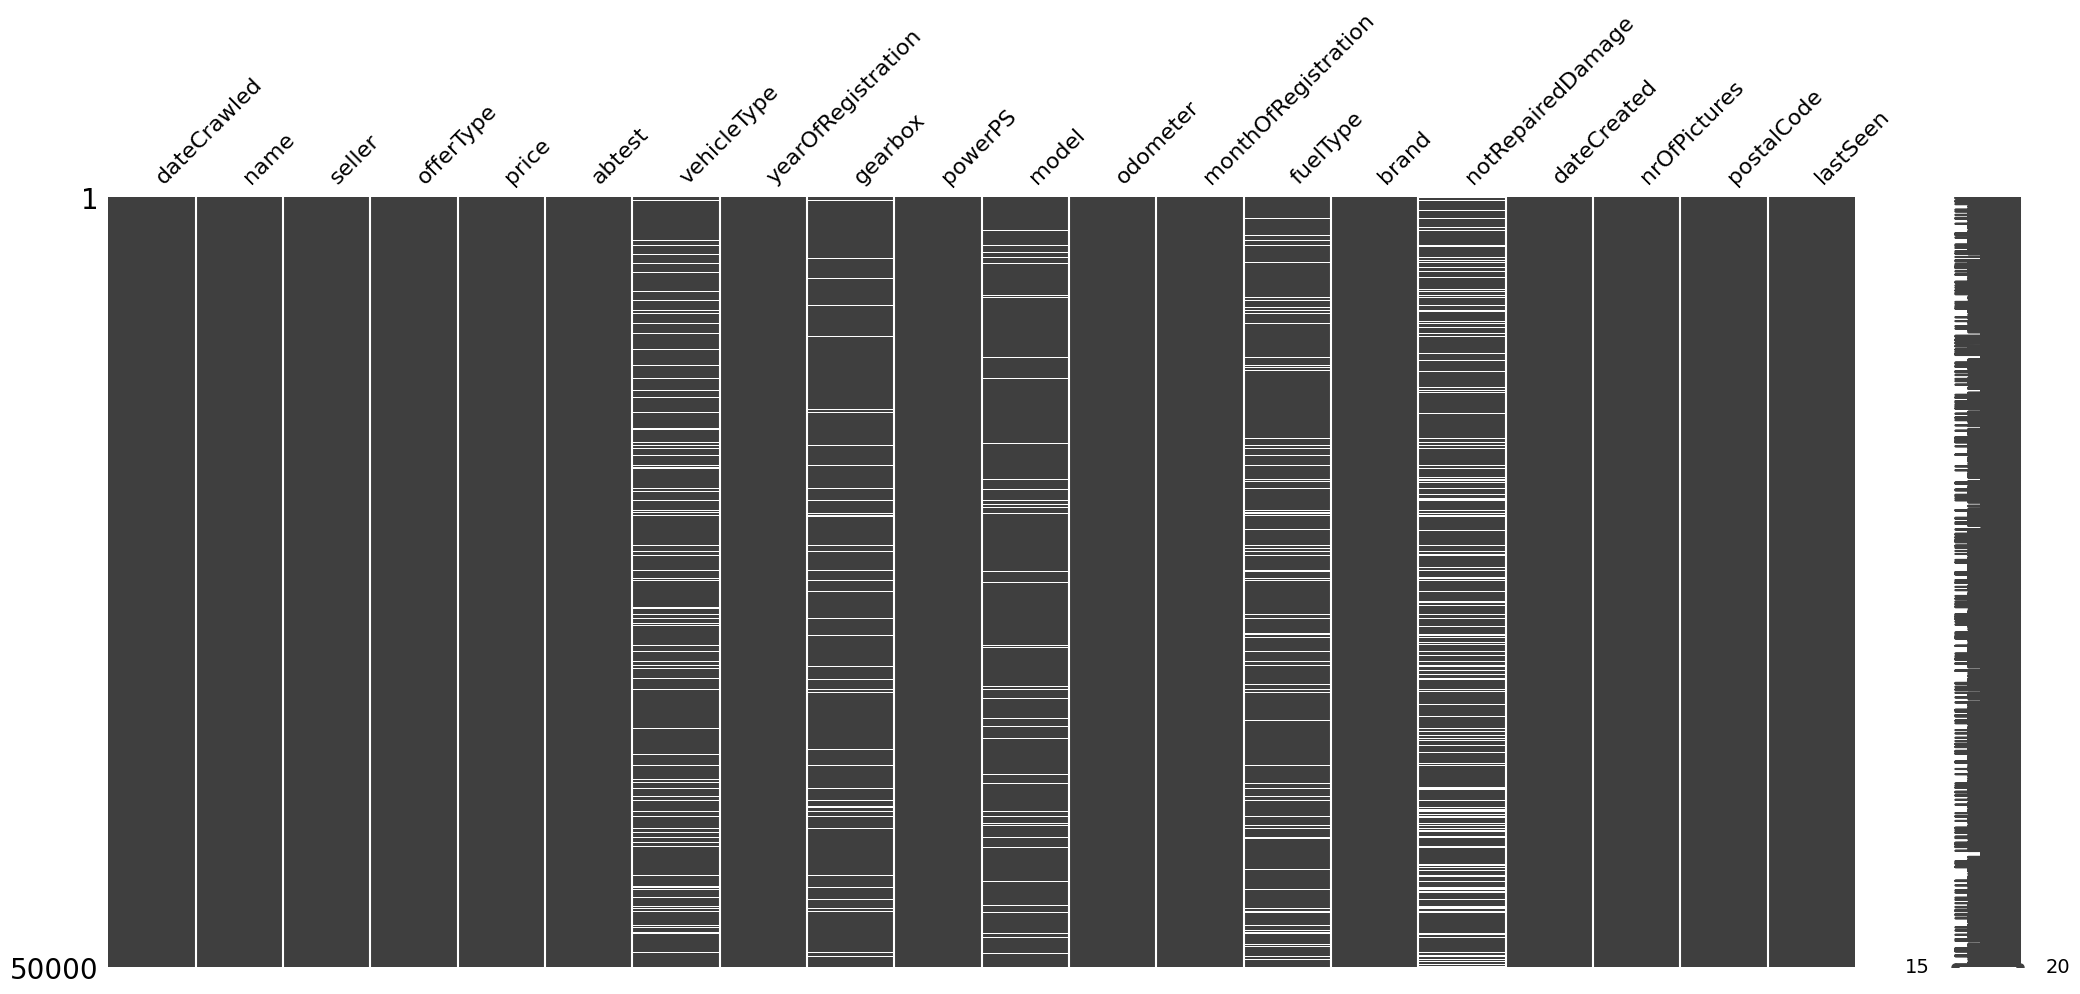

In [13]:
msno.matrix(autos)

In [14]:
#exploring missing values
for col in ['vehicleType', 'gearbox', 'model', 'fuelType', 'notRepairedDamage']:
    print(f"\n{col} value counts:")
    print(autos[col].value_counts(dropna=False).head())



vehicleType value counts:
vehicleType
limousine     12859
kleinwagen    10822
kombi          9127
NaN            5095
bus            4093
Name: count, dtype: int64

gearbox value counts:
gearbox
manuell      36993
automatik    10327
NaN           2680
Name: count, dtype: int64

model value counts:
model
golf      4024
andere    3528
3er       2761
NaN       2758
polo      1757
Name: count, dtype: int64

fuelType value counts:
fuelType
benzin    30107
diesel    14567
NaN        4482
lpg         691
cng          75
Name: count, dtype: int64

notRepairedDamage value counts:
notRepairedDamage
nein    35232
NaN      9829
ja       4939
Name: count, dtype: int64


In [15]:
autos['RepairedDamage'] = autos['notRepairedDamage'].replace({
    'nein': 'true',
    'ja': 'false'
})

In [16]:
#exploring all values
for col in ['dateCrawled','name','seller','offerType', 'price', 'abtest', 'vehicleType' ,'yearOfRegistration' ,'gearbox', 'powerPS' ,'model' ,'odometer' ,'monthOfRegistration' ,'fuelType', 'brand' ,'RepairedDamage' ,'dateCreated', 'postalCode', 'lastSeen']:
    print(f"\n{col} value counts:")
    print(autos[col].value_counts(dropna=False))



dateCrawled value counts:
dateCrawled
2016-03-29 23:42:13    3
2016-03-05 16:57:05    3
2016-03-25 19:57:10    3
2016-04-04 16:40:33    3
2016-03-08 10:40:35    3
                      ..
2016-03-22 17:36:42    1
2016-03-27 14:38:19    1
2016-03-28 10:50:25    1
2016-03-08 19:25:42    1
2016-03-26 18:57:24    1
Name: count, Length: 48213, dtype: int64

name value counts:
name
Ford_Fiesta                                                    78
BMW_316i                                                       75
Volkswagen_Golf_1.4                                            75
BMW_318i                                                       72
Volkswagen_Polo                                                72
                                                               ..
Audi_A3__1_8l__Silber;_schoenes_Fahrzeug                        1
Audi_A6__S6__Avant_4.2_quattro_eventuell_Tausch_moegl           1
Audi_Q5_3.0_TDI_qu._S_tr.__Navi__Panorama__Xenon                1
Opel_Astra_F_Cabrio_Berton

In [17]:
for col in ['RepairedDamage']:
    print(f"\n{col} value counts:")
    print(autos[col].value_counts(dropna=False).head())


RepairedDamage value counts:
RepairedDamage
true     35232
NaN       9829
false     4939
Name: count, dtype: int64


In [18]:
#abscence of data can be a sign of fraud
autos['vehicleType'].fillna('Unknown', inplace=True)
autos['gearbox'].fillna('Unknown', inplace=True)
autos['model'].fillna('Unknown', inplace=True)
autos['fuelType'].fillna('Unknown', inplace=True)
autos['notRepairedDamage'].fillna('Unknown', inplace=True)


C:\Users\hp\AppData\Local\Temp\ipykernel_14424\1891892467.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  autos['vehicleType'].fillna('Unknown', inplace=True)
C:\Users\hp\AppData\Local\Temp\ipykernel_14424\1891892467.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For examp

In [19]:
for col in ['vehicleType', 'gearbox', 'model', 'fuelType', 'notRepairedDamage']:
    print(f"\n{col} value counts:")
    print(autos[col].value_counts(dropna=False).head())


vehicleType value counts:
vehicleType
limousine     12859
kleinwagen    10822
kombi          9127
Unknown        5095
bus            4093
Name: count, dtype: int64

gearbox value counts:
gearbox
manuell      36993
automatik    10327
Unknown       2680
Name: count, dtype: int64

model value counts:
model
golf       4024
andere     3528
3er        2761
Unknown    2758
polo       1757
Name: count, dtype: int64

fuelType value counts:
fuelType
benzin     30107
diesel     14567
Unknown     4482
lpg          691
cng           75
Name: count, dtype: int64

notRepairedDamage value counts:
notRepairedDamage
nein       35232
Unknown     9829
ja          4939
Name: count, dtype: int64


# **Feature engineering**

In [20]:
#copy
df = autos.copy()

**Date processing** :
Year of registration anomalies

In [21]:
# Year of registration diagnostics
print('dtype:', df['yearOfRegistration'].dtype)
print('sample values:')
print(df['yearOfRegistration'].head(10))
print('describe:')
print(df['yearOfRegistration'].describe())
print('unique count:', df['yearOfRegistration'].nunique())
# show top problematic values that are outside realistic range or non-numeric
print('value counts (top 20):')
print(df['yearOfRegistration'].value_counts(dropna=False).head(20))
# attempt coercion to numeric to detect parsing issues
coerced = pd.to_numeric(df['yearOfRegistration'], errors='coerce')
num_invalid = coerced.isna().sum()
print(f'Non-convertible to numeric: {num_invalid} (will be NaN after coercion)')
# show problematic examples if any
if num_invalid > 0:
    print('Examples of non-convertible values:')
    print(df.loc[coerced.isna(), 'yearOfRegistration'].unique()[:20])

dtype: int64
sample values:
0    2004
1    1997
2    2009
3    2007
4    2003
5    2006
6    1995
7    1998
8    2000
9    1997
Name: yearOfRegistration, dtype: int64
describe:
count    50000.000000
mean      2005.073280
std        105.712813
min       1000.000000
25%       1999.000000
50%       2003.000000
75%       2008.000000
max       9999.000000
Name: yearOfRegistration, dtype: float64
unique count: 97
value counts (top 20):
yearOfRegistration
2000    3354
2005    3015
1999    3000
2004    2737
2003    2727
2006    2708
2001    2703
2002    2533
1998    2453
2007    2304
2008    2231
2009    2098
1997    2028
2011    1634
2010    1597
2017    1453
1996    1444
2012    1323
2016    1316
1995    1313
Name: count, dtype: int64
Non-convertible to numeric: 0 (will be NaN after coercion)


In [22]:
# Define realistic range
min_year, max_year = 1950, 2025

# Find anomalies
anomalies_year = df[(df['yearOfRegistration'] < min_year) | (df['yearOfRegistration'] > max_year)]

print("Number of year anomalies:", len(anomalies_year))
print(anomalies_year[['yearOfRegistration', 'price', 'brand', 'model']].head())

Number of year anomalies: 48
      yearOfRegistration   price           brand    model
453                 4500  $9,800            jeep   andere
2221                1934  $3,350            opel   andere
2573                1934  $3,000  sonstige_autos  Unknown
3679                1910      $1  sonstige_autos  Unknown
4164                5000     $49      volkswagen     golf


In [23]:
min_year, max_year = 1950, 2025

df['year_anomaly'] = df['yearOfRegistration'].apply(
    lambda x: 1 if (x < min_year or x > max_year) else 0
)

In [24]:
df.head()

,dateCrawled,name,seller,offerType,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,...,monthOfRegistration,fuelType,brand,notRepairedDamage,dateCreated,nrOfPictures,postalCode,lastSeen,RepairedDamage,year_anomaly
0,2016-03-26 17:47:46,Peugeot_807_160_NAVTECH_ON_BOARD,privat,Angebot,"$5,000",control,bus,2004,manuell,158,...,3,lpg,peugeot,nein,2016-03-26 00:00:00,0,79588,2016-04-06 06:45:54,true,0
1,2016-04-04 13:38:56,BMW_740i_4_4_Liter_HAMANN_UMBAU_Mega_Optik,privat,Angebot,"$8,500",control,limousine,1997,automatik,286,...,6,benzin,bmw,nein,2016-04-04 00:00:00,0,71034,2016-04-06 14:45:08,true,0
2,2016-03-26 18:57:24,Volkswagen_Golf_1.6_United,privat,Angebot,"$8,990",test,limousine,2009,manuell,102,...,7,benzin,volkswagen,nein,2016-03-26 00:00:00,0,35394,2016-04-06 20:15:37,true,0
3,2016-03-12 16:58:10,Smart_smart_fortwo_coupe_softouch/F1/Klima/Pan...,privat,Angebot,"$4,350",control,kleinwagen,2007,automatik,71,...,6,benzin,smart,nein,2016-03-12 00:00:00,0,33729,2016-03-15 03:16:28,true,0
4,2016-04-01 14:38:50,Ford_Focus_1_6_Benzin_TÜV_neu_ist_sehr_gepfleg...,privat,Angebot,"$1,350",test,kombi,2003,manuell,0,...,7,benzin,ford,nein,2016-04-01 00:00:00,0,39218,2016-04-01 14:38:50,true,0


**Mileage anomaly**

In [25]:
current_year = datetime.datetime.now().year  # e.g., 2025

df['car_age'] = current_year - df['yearOfRegistration']

In [26]:
print(df['odometer'].describe())
print(df['odometer'].head(10))
print(df['odometer'].dtype)


count         50000
unique           13
top       150,000km
freq          32424
Name: odometer, dtype: object
0    150,000km
1    150,000km
2     70,000km
3     70,000km
4    150,000km
5    150,000km
6    150,000km
7    150,000km
8    150,000km
9    150,000km
Name: odometer, dtype: object
object


In [27]:
# Ensure odometer is float (robust cleaning). Back up original to 'odometer_raw' if not present.
print('Current odometer dtype:', autos['odometer'].dtype)
if 'odometer_raw' not in autos.columns:
    autos['odometer_raw'] = autos['odometer']
    print("Backed up original column to 'odometer_raw'")
# If already numeric, just ensure float64 dtype
if pd.api.types.is_numeric_dtype(autos['odometer']):
    autos['odometer'] = autos['odometer'].astype('float64')
    print('Converted existing numeric odometer to float64')
else:
    # Remove 'km' (case-insensitive), commas and strip spaces
    cleaned = autos['odometer'].astype(str).str.replace(r'km', '', case=False, regex=True)
    cleaned = cleaned.str.replace(',', '', regex=False).str.strip()
    # Remove any remaining non-digit characters except decimal point
    cleaned = cleaned.str.replace(r'[^0-9.]', '', regex=True)
    # Replace empty strings with NA
    cleaned = cleaned.replace('', pd.NA)
    autos['odometer'] = pd.to_numeric(cleaned, errors='coerce').astype('float64')
    print('Converted odometer from strings to float64')
print('After conversion dtype:', autos['odometer'].dtype)
print(autos['odometer'].head(10))
print('Number of NaNs after conversion:', autos['odometer'].isna().sum())

Current odometer dtype: object
Backed up original column to 'odometer_raw'
Converted odometer from strings to float64
After conversion dtype: float64
0    150000.0
1    150000.0
2     70000.0
3     70000.0
4    150000.0
5    150000.0
6    150000.0
7    150000.0
8    150000.0
9    150000.0
Name: odometer, dtype: float64
Number of NaNs after conversion: 0


In [28]:
# Ensure df has a 'car_age' column; compute from yearOfRegistration if missing
import datetime
current_year = datetime.datetime.now().year
if 'car_age' not in df.columns and 'yearOfRegistration' in df.columns:
    df['car_age'] = current_year - pd.to_numeric(df['yearOfRegistration'], errors='coerce')
    print('df[] from yearOfRegistration')
# Ensure df['odometer'] is numeric (coerce if needed)
if not pd.api.types.is_numeric_dtype(df['odometer']):
    cleaned = df['odometer'].astype(str).str.replace(r'km', '', case=False, regex=True)
    cleaned = cleaned.str.replace(',', '', regex=False).str.strip()
    cleaned = cleaned.str.replace(r'[^0-9.]', '', regex=True).replace('', pd.NA)
    df['odometer'] = pd.to_numeric(cleaned, errors='coerce').astype('float64')
print('df dtypes:')
print(df[['car_age','odometer']].dtypes)
print(df[['car_age','odometer']].head())

df dtypes:
car_age       int64
odometer    float64
dtype: object
   car_age  odometer
0       21  150000.0
1       28  150000.0
2       16   70000.0
3       18   70000.0
4       22  150000.0


In [29]:
df['car_age'].describe()

count    50000.000000
mean        19.926720
std        105.712813
min      -7974.000000
25%         17.000000
50%         22.000000
75%         26.000000
max       1025.000000
Name: car_age, dtype: float64

In [30]:
# Filtering out unrealistic values
df_filtered = df[(df['car_age'] >= 0) & (df['car_age'] <= 40) &
                 (df['odometer'] >= 0) & (df['odometer'] <= 500000)]

In [31]:
#kilometrage per year
df_filtered['km_per_year'] = df_filtered['odometer'] / df_filtered['car_age'].replace(0, 1)


C:\Users\hp\AppData\Local\Temp\ipykernel_14424\365676400.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['km_per_year'] = df_filtered['odometer'] / df_filtered['car_age'].replace(0, 1)


In [32]:
#flag anomalies
df_filtered['mileage_anomaly'] = df_filtered['km_per_year'].apply(
    lambda x: 1 if (x < 5000 or x > 50000) else 0
)

C:\Users\hp\AppData\Local\Temp\ipykernel_14424\187898620.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['mileage_anomaly'] = df_filtered['km_per_year'].apply(


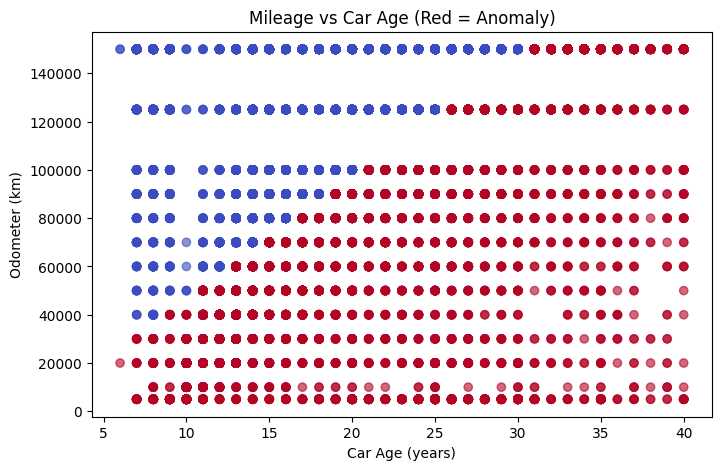

In [33]:
plt.figure(figsize=(8,5))
plt.scatter(df_filtered['car_age'], df_filtered['odometer'],
            c=df_filtered['mileage_anomaly'], cmap='coolwarm', alpha=0.6)
plt.xlabel('Car Age (years)')
plt.ylabel('Odometer (km)')
plt.title('Mileage vs Car Age (Red = Anomaly)')
plt.show()

Number of mileage anomalies: 11411


,dateCrawled,name,seller,offerType,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,odometer,monthOfRegistration,fuelType,brand,notRepairedDamage,dateCreated,nrOfPictures,postalCode,lastSeen,RepairedDamage,year_anomaly,car_age,km_per_year,mileage_anomaly,powerPS_raw,power_anomaly,repair_anomaly,duplicate_anomaly,temporal_anomaly_1,temporal_anomaly_2,ad_duration,temporal_anomaly_3,temporal_anomaly,fuelType_anomaly,gearbox_anomaly,vehicleType_anomaly,brand_anomaly,fraud_score
2,2016-03-26 18:57:24,Volkswagen_Golf_1.6_United,privat,Angebot,"$8,990",test,sedan,2009,manual,102,golf,70000.0,7,petrol,volkswagen,nein,2016-03-26,0,35394,2016-04-06 20:15:37,true,0,16,4375.000000,1,102,0,0,1,0,0,11,0,0,0,0,0,0,2
3,2016-03-12 16:58:10,Smart_smart_fortwo_coupe_softouch/F1/Klima/Pan...,privat,Angebot,"$4,350",control,small_car,2007,automatic,71,fortwo,70000.0,6,petrol,smart,nein,2016-03-12,0,33729,2016-03-15 03:16:28,true,0,18,3888.888889,1,71,0,0,1,0,0,3,0,0,0,0,0,0,2
12,2016-03-31 19:48:22,Smart_smart_fortwo_coupe_softouch_pure_MHD_Pan...,privat,Angebot,"$5,299",control,small_car,2010,automatic,71,fortwo,50000.0,9,petrol,smart,nein,2016-03-31,0,34590,2016-04-06 14:17:52,true,0,15,3333.333333,1,71,0,0,1,0,0,6,0,0,0,0,0,0,2
17,2016-03-29 11:46:22,Volkswagen_Scirocco_2_G60,privat,Angebot,"$5,500",test,coupe,1990,manual,205,scirocco,150000.0,6,petrol,volkswagen,nein,2016-03-29,0,74821,2016-04-05 20:46:26,true,0,35,4285.714286,1,205,0,0,1,0,0,7,0,0,0,0,0,0,2
22,2016-03-28 20:50:54,MINI_Cooper_S_Cabrio,privat,Angebot,"$25,450",control,convertible,2015,manual,184,cooper,10000.0,1,petrol,mini,nein,2016-03-28,0,44789,2016-04-01 06:45:30,true,0,10,1000.000000,1,184,0,0,1,0,0,4,0,0,0,0,0,0,2
24,2016-04-03 11:57:02,BMW_535i_xDrive_Sport_Aut.,privat,Angebot,"$48,500",control,sedan,2014,automatic,306,5er,30000.0,12,petrol,bmw,nein,2016-04-03,0,22547,2016-04-07 13:16:50,true,0,11,2727.272727,1,306,0,0,1,0,0,4,0,0,0,0,0,0,2
26,2016-04-03 22:46:28,Volkswagen_Polo_Fox,privat,Angebot,$777,control,small_car,1992,manual,54,polo,125000.0,2,petrol,volkswagen,nein,2016-04-03,0,38110,2016-04-05 23:46:48,true,0,33,3787.878788,1,54,0,0,1,0,0,2,0,0,0,0,0,0,2
42,2016-03-22 21:37:03,Vw_Polo_l.0_/60_PS_Blue_Motion_Technologie_Son...,privat,Angebot,"$11,900",control,small_car,2014,manual,60,polo,20000.0,7,petrol,volkswagen,Unknown,2016-03-22,0,26629,2016-04-06 18:44:39,NaN,0,11,1818.181818,1,60,0,1,1,0,0,15,0,0,0,0,0,0,3
43,2016-03-08 16:51:22,Audi_A1_1.2_TFSI_Attraction_mit_Garantie,privat,Angebot,"$11,500",test,small_car,2011,manual,86,a1,60000.0,9,petrol,audi,nein,2016-03-08,0,85049,2016-04-07 03:16:05,true,0,14,4285.714286,1,86,0,0,1,0,0,30,0,0,0,0,0,0,2
49,2016-03-27 15:36:42,Mercedes_Benz_CL_500__BlueEFFICIENCY__7G_TRONIC,privat,Angebot,"$56,000",control,coupe,2012,automatic,435,cl,60000.0,2,petrol,mercedes_benz,nein,2016-03-27,0,34474,2016-04-05 11:47:52,true,0,13,4615.384615,1,435,0,0,0,0,0,9,0,0,0,0,0,0,1


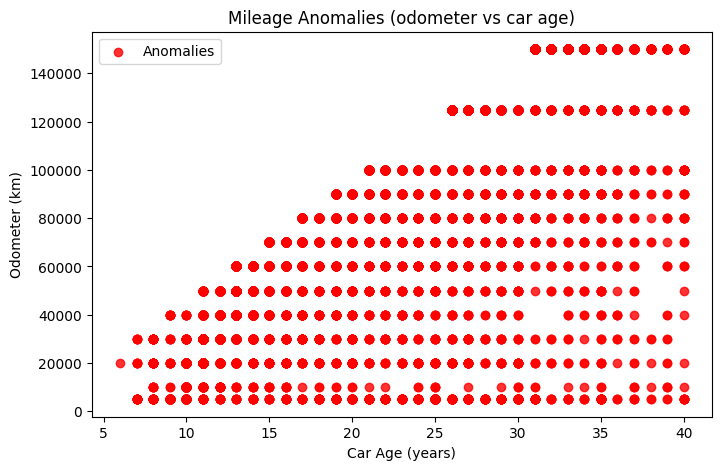

C:\Users\hp\AppData\Local\Temp\ipykernel_14424\3468510218.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_brands.values, y=top_brands.index, palette='Reds_r')


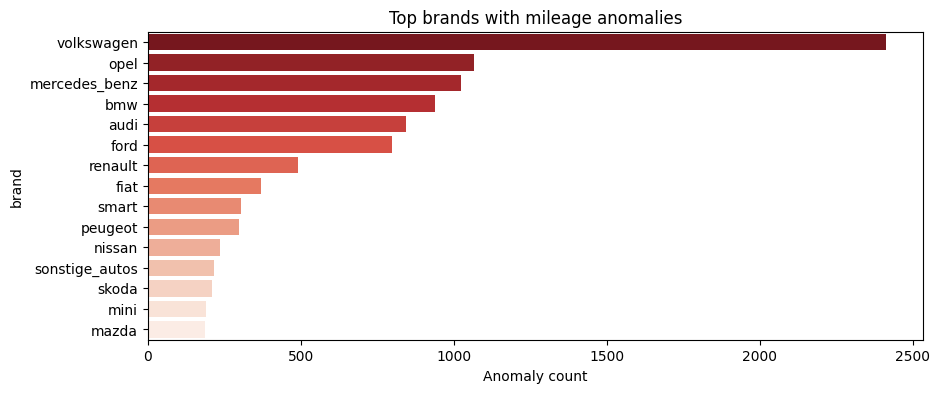

In [67]:
# Visualize only mileage anomalies
anomalies = df_filtered[df_filtered['mileage_anomaly'] == 1].copy()
print('Number of mileage anomalies:', len(anomalies))
if len(anomalies) > 0:
    display(anomalies.head(20))
    # Focused scatter of anomalies
    plt.figure(figsize=(8,5))
    plt.scatter(anomalies['car_age'], anomalies['odometer'], c='red', alpha=0.8, label='Anomalies')
    plt.xlabel('Car Age (years)')
    plt.ylabel('Odometer (km)')
    plt.title('Mileage Anomalies (odometer vs car age)')
    plt.legend()
    plt.show()
    # Breakdown by brand if available
    if 'brand' in anomalies.columns:
        top_brands = anomalies['brand'].value_counts().head(15)
        plt.figure(figsize=(10,4))
        sns.barplot(x=top_brands.values, y=top_brands.index, palette='Reds_r')
        plt.xlabel('Anomaly count')
        plt.title('Top brands with mileage anomalies')
        plt.show()
else:
    print('No anomalies found to visualize.')

In [35]:
df_filtered.head(5)

,dateCrawled,name,seller,offerType,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,...,notRepairedDamage,dateCreated,nrOfPictures,postalCode,lastSeen,RepairedDamage,year_anomaly,car_age,km_per_year,mileage_anomaly
0,2016-03-26 17:47:46,Peugeot_807_160_NAVTECH_ON_BOARD,privat,Angebot,"$5,000",control,bus,2004,manuell,158,...,nein,2016-03-26 00:00:00,0,79588,2016-04-06 06:45:54,true,0,21,7142.857143,0
1,2016-04-04 13:38:56,BMW_740i_4_4_Liter_HAMANN_UMBAU_Mega_Optik,privat,Angebot,"$8,500",control,limousine,1997,automatik,286,...,nein,2016-04-04 00:00:00,0,71034,2016-04-06 14:45:08,true,0,28,5357.142857,0
2,2016-03-26 18:57:24,Volkswagen_Golf_1.6_United,privat,Angebot,"$8,990",test,limousine,2009,manuell,102,...,nein,2016-03-26 00:00:00,0,35394,2016-04-06 20:15:37,true,0,16,4375.000000,1
3,2016-03-12 16:58:10,Smart_smart_fortwo_coupe_softouch/F1/Klima/Pan...,privat,Angebot,"$4,350",control,kleinwagen,2007,automatik,71,...,nein,2016-03-12 00:00:00,0,33729,2016-03-15 03:16:28,true,0,18,3888.888889,1
4,2016-04-01 14:38:50,Ford_Focus_1_6_Benzin_TÜV_neu_ist_sehr_gepfleg...,privat,Angebot,"$1,350",test,kombi,2003,manuell,0,...,nein,2016-04-01 00:00:00,0,39218,2016-04-01 14:38:50,true,0,22,6818.181818,0


**Power (powerPS) Anomalies.**

In [36]:
print(df_filtered['powerPS'].describe())
print(df_filtered['powerPS'].head(10))


count    49163.000000
mean       116.851128
std        210.293314
min          0.000000
25%         71.000000
50%        105.000000
75%        150.000000
max      17700.000000
Name: powerPS, dtype: float64
0    158
1    286
2    102
3     71
4      0
5    150
6     90
7     90
8      0
9     90
Name: powerPS, dtype: int64


Total rows in df_filtered: 49163
Number of power anomalies (NaN or outside [20, 1000]): 5353
Examples of anomalous rows (head):


C:\Users\hp\AppData\Local\Temp\ipykernel_14424\4197419957.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['powerPS_raw'] = df_filtered['powerPS']
C:\Users\hp\AppData\Local\Temp\ipykernel_14424\4197419957.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['powerPS'] = pd.to_numeric(power_series, errors='coerce')
C:\Users\hp\AppData\Local\Temp\ipykernel_14424\4197419957.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .lo

,dateCrawled,name,seller,offerType,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,...,nrOfPictures,postalCode,lastSeen,RepairedDamage,year_anomaly,car_age,km_per_year,mileage_anomaly,powerPS_raw,power_anomaly
4,2016-04-01 14:38:50,Ford_Focus_1_6_Benzin_TÜV_neu_ist_sehr_gepfleg...,privat,Angebot,"$1,350",test,kombi,2003,manuell,0,...,0,39218,2016-04-01 14:38:50,true,0,22,6818.181818,0,0,1
8,2016-03-22 16:51:34,Seat_Arosa,privat,Angebot,$250,test,Unknown,2000,manuell,0,...,0,7426,2016-03-26 18:18:10,true,0,25,6000.000000,0,0,1
11,2016-03-16 18:45:34,Mercedes_A140_Motorschaden,privat,Angebot,$350,control,Unknown,2000,Unknown,0,...,0,17498,2016-03-16 18:45:34,NaN,0,25,6000.000000,0,0,1
27,2016-03-27 18:45:01,Hat_einer_Ahnung_mit_Ford_Galaxy_HILFE,privat,Angebot,$0,control,Unknown,2005,Unknown,0,...,0,66701,2016-03-27 18:45:01,NaN,0,20,7500.000000,0,0,1
32,2016-03-20 05:03:03,Corsa_mit_TÜV_5.2016,privat,Angebot,$350,control,kleinwagen,1999,manuell,0,...,0,27619,2016-04-06 03:15:20,NaN,0,26,5769.230769,0,0,1


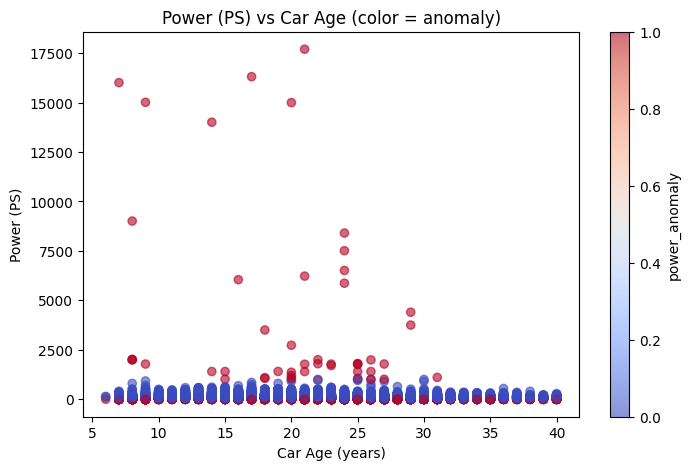

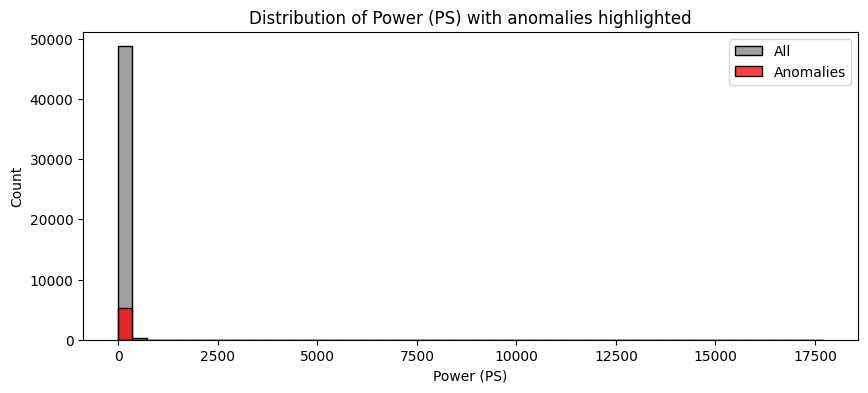

C:\Users\hp\AppData\Local\Temp\ipykernel_14424\4197419957.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_brands.values, y=top_brands.index, palette='viridis')


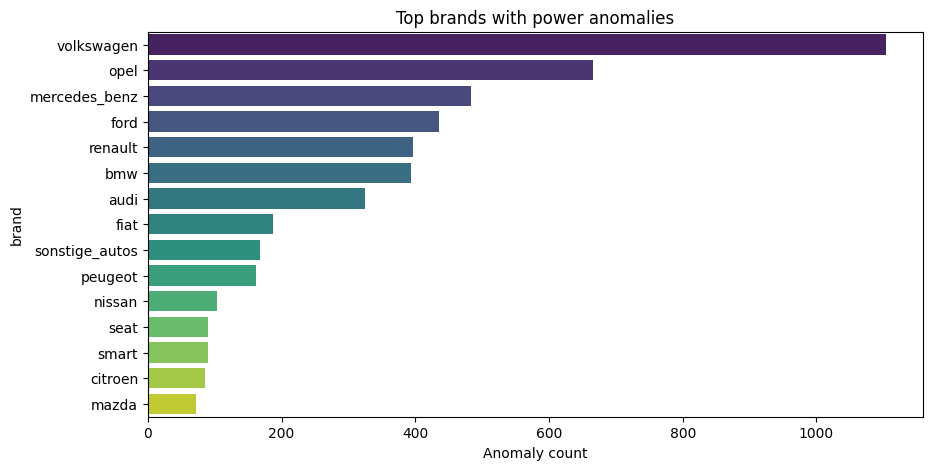

In [37]:
# Horsepower (powerPS) anomalies: robust coercion, flagging and visualization
# Back up raw column if not already backed up
if 'powerPS_raw' not in df_filtered.columns and 'powerPS' in df_filtered.columns:
    df_filtered['powerPS_raw'] = df_filtered['powerPS']

# Coerce to numeric (handle strings like '100,0' or '100.00' or '100 000')
power_series = df_filtered['powerPS'].astype(str).str.replace(r'\s+', '', regex=True).str.replace(',', '.', regex=False)
df_filtered['powerPS'] = pd.to_numeric(power_series, errors='coerce')

# Define realistic horsepower bounds and flag anomalies: out-of-range or missing
min_power, max_power = 20, 1000  # very wide bounds to catch extremes; adjust if desired
df_filtered['power_anomaly'] = df_filtered['powerPS'].apply(lambda x: 1 if (pd.isna(x) or x < min_power or x > max_power) else 0)

# Summary counts
total = len(df_filtered)
anoms = df_filtered['power_anomaly'].sum()
print(f'Total rows in df_filtered: {total}')
print(f'Number of power anomalies (NaN or outside [{min_power}, {max_power}]): {anoms}')
print('Examples of anomalous rows (head):')
display(df_filtered[df_filtered['power_anomaly'] == 1].head(5))

# Visualizations: scatter (power vs age), histogram of power, and top brands with anomalies
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter: power vs car_age (color by anomaly)
plt.figure(figsize=(8,5))
plt.scatter(df_filtered['car_age'], df_filtered['powerPS'], c=df_filtered['power_anomaly'], cmap='coolwarm', alpha=0.6)
plt.xlabel('Car Age (years)')
plt.ylabel('Power (PS)')
plt.title('Power (PS) vs Car Age (color = anomaly)')
plt.colorbar(label='power_anomaly')
plt.show()

# Histogram of power values (non-anomalous vs anomalous overlay)
plt.figure(figsize=(10,4))
sns.histplot(df_filtered['powerPS'].dropna(), bins=50, kde=False, color='grey', label='All')
sns.histplot(df_filtered.loc[df_filtered['power_anomaly']==1, 'powerPS'].dropna(), bins=50, kde=False, color='red', label='Anomalies')
plt.xlabel('Power (PS)')
plt.title('Distribution of Power (PS) with anomalies highlighted')
plt.legend()
plt.show()

# Top brands among anomalies (if brand exists)
if 'brand' in df_filtered.columns:
    top_brands = df_filtered[df_filtered['power_anomaly']==1]['brand'].value_counts().head(15)
    if len(top_brands) > 0:
        plt.figure(figsize=(10,5))
        sns.barplot(x=top_brands.values, y=top_brands.index, palette='viridis')
        plt.xlabel('Anomaly count')
        plt.title('Top brands with power anomalies')
        plt.show()

# Keep the df and df_filtered state consistent for downstream cells

In [38]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49163 entries, 0 to 49999
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   dateCrawled          49163 non-null  object 
 1   name                 49163 non-null  object 
 2   seller               49163 non-null  object 
 3   offerType            49163 non-null  object 
 4   price                49163 non-null  object 
 5   abtest               49163 non-null  object 
 6   vehicleType          49163 non-null  object 
 7   yearOfRegistration   49163 non-null  int64  
 8   gearbox              49163 non-null  object 
 9   powerPS              49163 non-null  int64  
 10  model                49163 non-null  object 
 11  odometer             49163 non-null  float64
 12  monthOfRegistration  49163 non-null  int64  
 13  fuelType             49163 non-null  object 
 14  brand                49163 non-null  object 
 15  notRepairedDamage    49163 non-null  obje

In [39]:
pd.set_option('display.max_columns', None)

df_filtered.head(3)

,dateCrawled,name,seller,offerType,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,odometer,monthOfRegistration,fuelType,brand,notRepairedDamage,dateCreated,nrOfPictures,postalCode,lastSeen,RepairedDamage,year_anomaly,car_age,km_per_year,mileage_anomaly,powerPS_raw,power_anomaly
0,2016-03-26 17:47:46,Peugeot_807_160_NAVTECH_ON_BOARD,privat,Angebot,"$5,000",control,bus,2004,manuell,158,andere,150000.0,3,lpg,peugeot,nein,2016-03-26 00:00:00,0,79588,2016-04-06 06:45:54,true,0,21,7142.857143,0,158,0
1,2016-04-04 13:38:56,BMW_740i_4_4_Liter_HAMANN_UMBAU_Mega_Optik,privat,Angebot,"$8,500",control,limousine,1997,automatik,286,7er,150000.0,6,benzin,bmw,nein,2016-04-04 00:00:00,0,71034,2016-04-06 14:45:08,true,0,28,5357.142857,0,286,0
2,2016-03-26 18:57:24,Volkswagen_Golf_1.6_United,privat,Angebot,"$8,990",test,limousine,2009,manuell,102,golf,70000.0,7,benzin,volkswagen,nein,2016-03-26 00:00:00,0,35394,2016-04-06 20:15:37,true,0,16,4375.000000,1,102,0


In [40]:
pd.set_option('display.max_columns', None)

df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49163 entries, 0 to 49999
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   dateCrawled          49163 non-null  object 
 1   name                 49163 non-null  object 
 2   seller               49163 non-null  object 
 3   offerType            49163 non-null  object 
 4   price                49163 non-null  object 
 5   abtest               49163 non-null  object 
 6   vehicleType          49163 non-null  object 
 7   yearOfRegistration   49163 non-null  int64  
 8   gearbox              49163 non-null  object 
 9   powerPS              49163 non-null  int64  
 10  model                49163 non-null  object 
 11  odometer             49163 non-null  float64
 12  monthOfRegistration  49163 non-null  int64  
 13  fuelType             49163 non-null  object 
 14  brand                49163 non-null  object 
 15  notRepairedDamage    49163 non-null  obje

In [41]:
print(f"Total columns: {len(df_filtered.columns)}")
for i, col in enumerate(df_filtered.columns):
    dtype = df_filtered[col].dtype
    print(f"{i:2d}. {col} - {dtype}")

Total columns: 27
 0. dateCrawled - object
 1. name - object
 2. seller - object
 3. offerType - object
 4. price - object
 5. abtest - object
 6. vehicleType - object
 7. yearOfRegistration - int64
 8. gearbox - object
 9. powerPS - int64
10. model - object
11. odometer - float64
12. monthOfRegistration - int64
13. fuelType - object
14. brand - object
15. notRepairedDamage - object
16. dateCreated - object
17. nrOfPictures - int64
18. postalCode - int64
19. lastSeen - object
20. RepairedDamage - object
21. year_anomaly - int64
22. car_age - int64
23. km_per_year - float64
24. mileage_anomaly - int64
25. powerPS_raw - int64
26. power_anomaly - int64


**Repared damage anomaly**

In [42]:
df_filtered['RepairedDamage']==False

0        False
1        False
2        False
3        False
4        False
         ...  
49995    False
49996    False
49997    False
49998    False
49999    False
Name: RepairedDamage, Length: 49163, dtype: bool

In [43]:
# Count RepairedDamage values (true / false / Unknown) and show samples
if 'RepairedDamage' in df_filtered.columns:
    counts = df_filtered['RepairedDamage'].value_counts(dropna=False)
    print('Raw counts (including NaN):')
    print(counts)
    
    print('\nProportions:')
    print((counts / len(df_filtered)).round(4))
    
    # Normalize values to 'true', 'false', 'unknown' for a clearer view
    normalized = df_filtered['RepairedDamage'].fillna('Unknown').astype(str).str.strip().str.lower()
    normalized = normalized.replace({'nan': 'unknown'})
    
    print('\nNormalized counts (true/false/unknown):')
    print(normalized.value_counts())    
            
else:
    print('Column RepairedDamage not found in df_filtered. Checking autos...')
    if 'RepairedDamage' in autos.columns:
        counts = autos['RepairedDamage'].value_counts(dropna=False)
        print('Counts from autos (including NaN):')
        print(counts)
    else:
        print('RepairedDamage not found in autos either.')

Raw counts (including NaN):
RepairedDamage
true     34752
NaN       9543
false     4868
Name: count, dtype: int64

Proportions:
RepairedDamage
true     0.7069
NaN      0.1941
false    0.0990
Name: count, dtype: float64

Normalized counts (true/false/unknown):
RepairedDamage
true       34752
unknown     9543
false       4868
Name: count, dtype: int64


In [44]:
df_filtered['repair_anomaly'] = df_filtered['RepairedDamage'].isna().astype(int)

C:\Users\hp\AppData\Local\Temp\ipykernel_14424\2570855746.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['repair_anomaly'] = df_filtered['RepairedDamage'].isna().astype(int)


<Axes: title={'center': 'Repair Status Distribution'}, xlabel='repair_anomaly'>

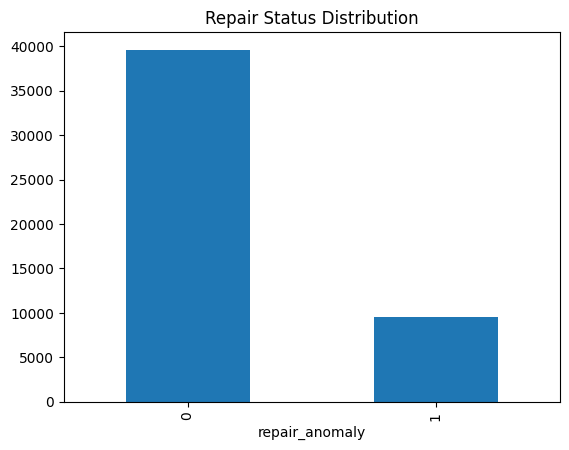

In [45]:
df_filtered['repair_anomaly'].value_counts().plot(kind='bar', title='Repair Status Distribution')


**Duplicate or Suspicious Listings**

In [46]:
df_filtered.duplicated().sum()

np.int64(0)

In [47]:
#check for near duplicates
potential_duplicates = (
    df_filtered.groupby(['brand', 'model', 'yearOfRegistration', 'odometer'])
    .filter(lambda x: len(x) > 1)
    .sort_values(['brand', 'model', 'yearOfRegistration'])
)
print(f'Number of potential near-duplicate groups: {len(potential_duplicates)}')

Number of potential near-duplicate groups: 42343


In [48]:
df_filtered['duplicate_anomaly'] = 0
duplicate_idx = df_filtered[df_filtered[['brand', 'model', 'yearOfRegistration', 'odometer']].duplicated(keep=False)].index
df_filtered.loc[duplicate_idx, 'duplicate_anomaly'] = 1


C:\Users\hp\AppData\Local\Temp\ipykernel_14424\1902045369.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['duplicate_anomaly'] = 0


In [49]:
df_filtered[df_filtered['duplicate_anomaly'] == 1].head(10)


,dateCrawled,name,seller,offerType,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,odometer,monthOfRegistration,fuelType,brand,notRepairedDamage,dateCreated,nrOfPictures,postalCode,lastSeen,RepairedDamage,year_anomaly,car_age,km_per_year,mileage_anomaly,powerPS_raw,power_anomaly,repair_anomaly,duplicate_anomaly
0,2016-03-26 17:47:46,Peugeot_807_160_NAVTECH_ON_BOARD,privat,Angebot,"$5,000",control,bus,2004,manuell,158,andere,150000.0,3,lpg,peugeot,nein,2016-03-26 00:00:00,0,79588,2016-04-06 06:45:54,true,0,21,7142.857143,0,158,0,0,1
1,2016-04-04 13:38:56,BMW_740i_4_4_Liter_HAMANN_UMBAU_Mega_Optik,privat,Angebot,"$8,500",control,limousine,1997,automatik,286,7er,150000.0,6,benzin,bmw,nein,2016-04-04 00:00:00,0,71034,2016-04-06 14:45:08,true,0,28,5357.142857,0,286,0,0,1
2,2016-03-26 18:57:24,Volkswagen_Golf_1.6_United,privat,Angebot,"$8,990",test,limousine,2009,manuell,102,golf,70000.0,7,benzin,volkswagen,nein,2016-03-26 00:00:00,0,35394,2016-04-06 20:15:37,true,0,16,4375.000000,1,102,0,0,1
3,2016-03-12 16:58:10,Smart_smart_fortwo_coupe_softouch/F1/Klima/Pan...,privat,Angebot,"$4,350",control,kleinwagen,2007,automatik,71,fortwo,70000.0,6,benzin,smart,nein,2016-03-12 00:00:00,0,33729,2016-03-15 03:16:28,true,0,18,3888.888889,1,71,0,0,1
4,2016-04-01 14:38:50,Ford_Focus_1_6_Benzin_TÜV_neu_ist_sehr_gepfleg...,privat,Angebot,"$1,350",test,kombi,2003,manuell,0,focus,150000.0,7,benzin,ford,nein,2016-04-01 00:00:00,0,39218,2016-04-01 14:38:50,true,0,22,6818.181818,0,0,1,0,1
5,2016-03-21 13:47:45,Chrysler_Grand_Voyager_2.8_CRD_Aut.Limited_Sto...,privat,Angebot,"$7,900",test,bus,2006,automatik,150,voyager,150000.0,4,diesel,chrysler,Unknown,2016-03-21 00:00:00,0,22962,2016-04-06 09:45:21,NaN,0,19,7894.736842,0,150,0,1,1
6,2016-03-20 17:55:21,VW_Golf_III_GT_Special_Electronic_Green_Metall...,privat,Angebot,$300,test,limousine,1995,manuell,90,golf,150000.0,8,benzin,volkswagen,Unknown,2016-03-20 00:00:00,0,31535,2016-03-23 02:48:59,NaN,0,30,5000.000000,0,90,0,1,1
7,2016-03-16 18:55:19,Golf_IV_1.9_TDI_90PS,privat,Angebot,"$1,990",control,limousine,1998,manuell,90,golf,150000.0,12,diesel,volkswagen,nein,2016-03-16 00:00:00,0,53474,2016-04-07 03:17:32,true,0,27,5555.555556,0,90,0,0,1
8,2016-03-22 16:51:34,Seat_Arosa,privat,Angebot,$250,test,Unknown,2000,manuell,0,arosa,150000.0,10,Unknown,seat,nein,2016-03-22 00:00:00,0,7426,2016-03-26 18:18:10,true,0,25,6000.000000,0,0,1,0,1
9,2016-03-16 13:47:02,Renault_Megane_Scenic_1.6e_RT_Klimaanlage,privat,Angebot,$590,control,bus,1997,manuell,90,megane,150000.0,7,benzin,renault,nein,2016-03-16 00:00:00,0,15749,2016-04-06 10:46:35,true,0,28,5357.142857,0,90,0,0,1


Duplicate anomaly counts:
duplicate_anomaly
1    42343
0     6820
Name: count, dtype: int64

Sample duplicate rows (up to 10):


,dateCrawled,name,seller,offerType,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,odometer,monthOfRegistration,fuelType,brand,notRepairedDamage,dateCreated,nrOfPictures,postalCode,lastSeen,RepairedDamage,year_anomaly,car_age,km_per_year,mileage_anomaly,powerPS_raw,power_anomaly,repair_anomaly,duplicate_anomaly
0,2016-03-26 17:47:46,Peugeot_807_160_NAVTECH_ON_BOARD,privat,Angebot,"$5,000",control,bus,2004,manuell,158,andere,150000.0,3,lpg,peugeot,nein,2016-03-26 00:00:00,0,79588,2016-04-06 06:45:54,true,0,21,7142.857143,0,158,0,0,1
1,2016-04-04 13:38:56,BMW_740i_4_4_Liter_HAMANN_UMBAU_Mega_Optik,privat,Angebot,"$8,500",control,limousine,1997,automatik,286,7er,150000.0,6,benzin,bmw,nein,2016-04-04 00:00:00,0,71034,2016-04-06 14:45:08,true,0,28,5357.142857,0,286,0,0,1
2,2016-03-26 18:57:24,Volkswagen_Golf_1.6_United,privat,Angebot,"$8,990",test,limousine,2009,manuell,102,golf,70000.0,7,benzin,volkswagen,nein,2016-03-26 00:00:00,0,35394,2016-04-06 20:15:37,true,0,16,4375.000000,1,102,0,0,1
3,2016-03-12 16:58:10,Smart_smart_fortwo_coupe_softouch/F1/Klima/Pan...,privat,Angebot,"$4,350",control,kleinwagen,2007,automatik,71,fortwo,70000.0,6,benzin,smart,nein,2016-03-12 00:00:00,0,33729,2016-03-15 03:16:28,true,0,18,3888.888889,1,71,0,0,1
4,2016-04-01 14:38:50,Ford_Focus_1_6_Benzin_TÜV_neu_ist_sehr_gepfleg...,privat,Angebot,"$1,350",test,kombi,2003,manuell,0,focus,150000.0,7,benzin,ford,nein,2016-04-01 00:00:00,0,39218,2016-04-01 14:38:50,true,0,22,6818.181818,0,0,1,0,1
5,2016-03-21 13:47:45,Chrysler_Grand_Voyager_2.8_CRD_Aut.Limited_Sto...,privat,Angebot,"$7,900",test,bus,2006,automatik,150,voyager,150000.0,4,diesel,chrysler,Unknown,2016-03-21 00:00:00,0,22962,2016-04-06 09:45:21,NaN,0,19,7894.736842,0,150,0,1,1
6,2016-03-20 17:55:21,VW_Golf_III_GT_Special_Electronic_Green_Metall...,privat,Angebot,$300,test,limousine,1995,manuell,90,golf,150000.0,8,benzin,volkswagen,Unknown,2016-03-20 00:00:00,0,31535,2016-03-23 02:48:59,NaN,0,30,5000.000000,0,90,0,1,1
7,2016-03-16 18:55:19,Golf_IV_1.9_TDI_90PS,privat,Angebot,"$1,990",control,limousine,1998,manuell,90,golf,150000.0,12,diesel,volkswagen,nein,2016-03-16 00:00:00,0,53474,2016-04-07 03:17:32,true,0,27,5555.555556,0,90,0,0,1
8,2016-03-22 16:51:34,Seat_Arosa,privat,Angebot,$250,test,Unknown,2000,manuell,0,arosa,150000.0,10,Unknown,seat,nein,2016-03-22 00:00:00,0,7426,2016-03-26 18:18:10,true,0,25,6000.000000,0,0,1,0,1
9,2016-03-16 13:47:02,Renault_Megane_Scenic_1.6e_RT_Klimaanlage,privat,Angebot,$590,control,bus,1997,manuell,90,megane,150000.0,7,benzin,renault,nein,2016-03-16 00:00:00,0,15749,2016-04-06 10:46:35,true,0,28,5357.142857,0,90,0,0,1


C:\Users\hp\AppData\Local\Temp\ipykernel_14424\2849634141.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_brands.values, y=top_brands.index, palette='magma')


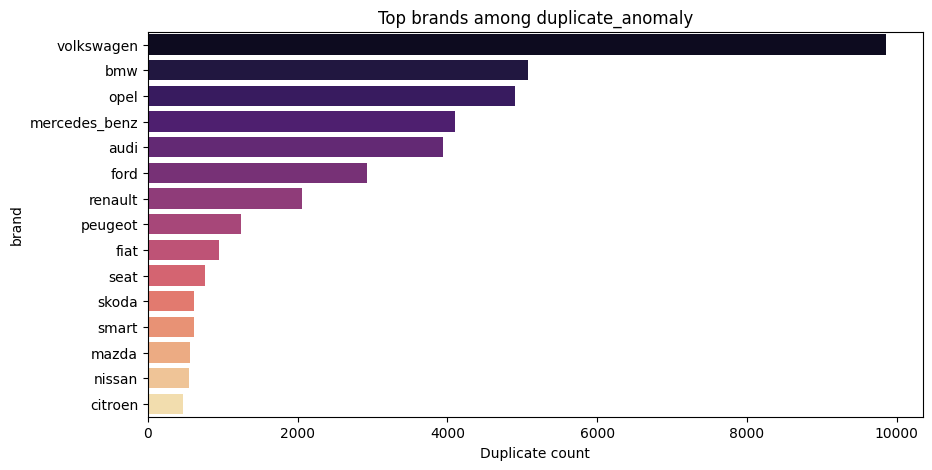

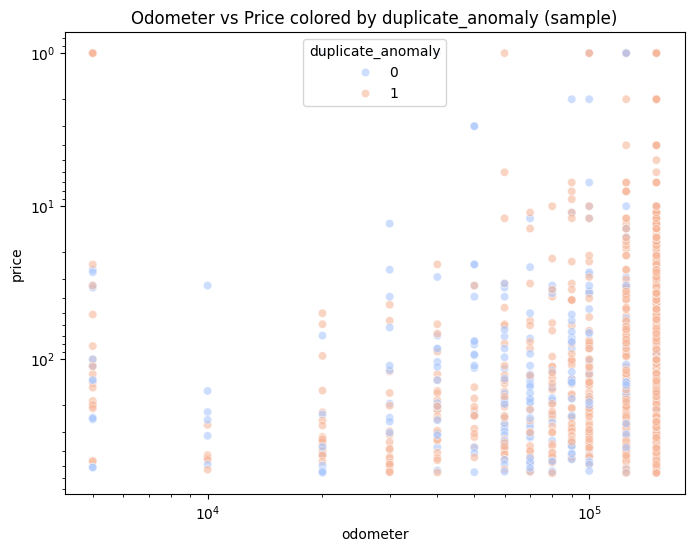

Done visualizing duplicate_anomaly


In [50]:
# Prefer df_filtered if it exists and contains the column, otherwise fall back to df
data = df_filtered if ('df_filtered' in globals() and 'duplicate_anomaly' in df_filtered.columns) else df
if 'duplicate_anomaly' not in data.columns:
    print('No duplicate_anomaly column found in df_filtered or df')
else:
    counts = data['duplicate_anomaly'].value_counts(dropna=False)
    print('Duplicate anomaly counts:')
    print(counts)
    print('\nSample duplicate rows (up to 10):')
    display(data[data['duplicate_anomaly'] == 1].head(10))
    # Bar chart of duplicates by brand if brand exists
    if 'brand' in data.columns:
        top_brands = data[data['duplicate_anomaly'] == 1]['brand'].value_counts().head(15)
        if len(top_brands) > 0:
            plt.figure(figsize=(10,5))
            sns.barplot(x=top_brands.values, y=top_brands.index, palette='magma')
            plt.xlabel('Duplicate count')
            plt.title('Top brands among duplicate_anomaly')
            plt.show()
    # Scatter: odometer vs price colored by duplicate flag (if columns exist)
    if set(['odometer','price']).issubset(data.columns):
        plt.figure(figsize=(8,6))
        sns.scatterplot(data=data.sample(min(2000, len(data))), x='odometer', y='price', hue='duplicate_anomaly', alpha=0.6, palette='coolwarm')
        plt.xscale('log')
        plt.yscale('log')
        plt.title('Odometer vs Price colored by duplicate_anomaly (sample)')
        plt.show()
    print('Done visualizing duplicate_anomaly')

**Temporal Inconsistencies Ads**

* dateCrawled : when the lisitng was scraped
* dateCreated : when the add was created 
* last seen : when the add was last online

In [51]:
df_filtered['dateCrawled'] = pd.to_datetime(df_filtered['dateCrawled'], errors='coerce')
df_filtered['dateCreated'] = pd.to_datetime(df_filtered['dateCreated'], errors='coerce')
df_filtered['lastSeen'] = pd.to_datetime(df_filtered['lastSeen'], errors='coerce')


C:\Users\hp\AppData\Local\Temp\ipykernel_14424\899093909.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['dateCrawled'] = pd.to_datetime(df_filtered['dateCrawled'], errors='coerce')
C:\Users\hp\AppData\Local\Temp\ipykernel_14424\899093909.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['dateCreated'] = pd.to_datetime(df_filtered['dateCreated'], errors='coerce')
C:\Users\hp\AppData\Local\Temp\ipykernel_14424\899093909.py:3: SettingWithCopyWarning: 
A value is trying to be set 

In [52]:
#add created before crawl date
df_filtered['temporal_anomaly_1'] = (df_filtered['dateCreated'] > df_filtered['dateCrawled']).astype(int)

C:\Users\hp\AppData\Local\Temp\ipykernel_14424\3445992031.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['temporal_anomaly_1'] = (df_filtered['dateCreated'] > df_filtered['dateCrawled']).astype(int)


In [53]:
print(f"Temporal anomalies: {df_filtered['temporal_anomaly_1'].sum():,} / {len(df_filtered):,}")

Temporal anomalies: 0 / 49,163


In [54]:
df_filtered['temporal_anomaly_2'] = (df_filtered['lastSeen'] < df_filtered['dateCreated']).astype(int)
print(f"Temporal anomalies: {df_filtered['temporal_anomaly_2'].sum():,} / {len(df_filtered):,}")

Temporal anomalies: 0 / 49,163


C:\Users\hp\AppData\Local\Temp\ipykernel_14424\2690619413.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['temporal_anomaly_2'] = (df_filtered['lastSeen'] < df_filtered['dateCreated']).astype(int)


In [55]:
df_filtered['ad_duration'] = (df_filtered['lastSeen'] - df_filtered['dateCreated']).dt.days
df_filtered['temporal_anomaly_3'] = ((df_filtered['ad_duration'] < 0) | (df_filtered['ad_duration'] > 365)).astype(int)
print(f"Temporal anomalies: {df_filtered['temporal_anomaly_3'].sum():,} / {len(df_filtered):,}")

Temporal anomalies: 0 / 49,163


C:\Users\hp\AppData\Local\Temp\ipykernel_14424\3023473754.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['ad_duration'] = (df_filtered['lastSeen'] - df_filtered['dateCreated']).dt.days
C:\Users\hp\AppData\Local\Temp\ipykernel_14424\3023473754.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['temporal_anomaly_3'] = ((df_filtered['ad_duration'] < 0) | (df_filtered['ad_duration'] > 365)).astype(int)


In [56]:
df_filtered['temporal_anomaly'] = (
    df_filtered['temporal_anomaly_1'] |
    df_filtered['temporal_anomaly_2'] |
    df_filtered['temporal_anomaly_3']
)


C:\Users\hp\AppData\Local\Temp\ipykernel_14424\2976556059.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['temporal_anomaly'] = (


In [57]:
print("Number of temporal anomalies:", df_filtered['temporal_anomaly'].sum())
df_filtered[df_filtered['temporal_anomaly'] == 1].head(10)


Number of temporal anomalies: 0


,dateCrawled,name,seller,offerType,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,odometer,monthOfRegistration,fuelType,brand,notRepairedDamage,dateCreated,nrOfPictures,postalCode,lastSeen,RepairedDamage,year_anomaly,car_age,km_per_year,mileage_anomaly,powerPS_raw,power_anomaly,repair_anomaly,duplicate_anomaly,temporal_anomaly_1,temporal_anomaly_2,ad_duration,temporal_anomaly_3,temporal_anomaly


No temporal anomalies

**Catgorial anomlies / mismatches**

In [58]:
categorical_cols = ['fuelType', 'gearbox', 'vehicleType', 'brand']

for col in categorical_cols:
    print(f"{col} unique values:")
    print(df_filtered[col].unique())
    print("\n")


fuelType unique values:
['lpg' 'benzin' 'diesel' 'Unknown' 'cng' 'hybrid' 'elektro' 'andere']


gearbox unique values:
['manuell' 'automatik' 'Unknown']


vehicleType unique values:
['bus' 'limousine' 'kleinwagen' 'kombi' 'Unknown' 'coupe' 'suv' 'cabrio'
 'andere']


brand unique values:
['peugeot' 'bmw' 'volkswagen' 'smart' 'ford' 'chrysler' 'seat' 'renault'
 'mercedes_benz' 'audi' 'opel' 'mazda' 'porsche' 'mini' 'toyota' 'dacia'
 'nissan' 'jeep' 'saab' 'volvo' 'mitsubishi' 'jaguar' 'fiat' 'skoda'
 'subaru' 'sonstige_autos' 'kia' 'citroen' 'chevrolet' 'hyundai' 'honda'
 'daewoo' 'suzuki' 'land_rover' 'alfa_romeo' 'lada' 'rover' 'trabant'
 'daihatsu' 'lancia']




In [59]:
# Normalize fuelType
fuel_map = {
    'benzin': 'petrol',
    'elektro': 'electric',
    'andere': 'other',
    'unknown': 'unknown'
}
df_filtered['fuelType'] = df_filtered['fuelType'].str.lower().replace(fuel_map)

# Normalize gearbox
gear_map = {'manuell': 'manual', 'automatik': 'automatic', 'unknown': 'unknown'}
df_filtered['gearbox'] = df_filtered['gearbox'].str.lower().replace(gear_map)

# Normalize vehicleType
vehicle_map = {
    'bus': 'bus',
    'limousine': 'sedan',
    'kleinwagen': 'small_car',
    'kombi': 'wagon',
    'coupe': 'coupe',
    'suv': 'suv',
    'cabrio': 'convertible',
    'andere': 'other',
    'unknown': 'unknown'
}
df_filtered['vehicleType'] = df_filtered['vehicleType'].str.lower().replace(vehicle_map)


C:\Users\hp\AppData\Local\Temp\ipykernel_14424\2781795761.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['fuelType'] = df_filtered['fuelType'].str.lower().replace(fuel_map)
C:\Users\hp\AppData\Local\Temp\ipykernel_14424\2781795761.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['gearbox'] = df_filtered['gearbox'].str.lower().replace(gear_map)
C:\Users\hp\AppData\Local\Temp\ipykernel_14424\2781795761.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a 

In [60]:
#valid categories
valid_categories = {
    'fuelType': ['petrol', 'diesel', 'lpg', 'cng', 'electric', 'hybrid', 'other'],
    'gearbox': ['manual', 'automatic'],
    'vehicleType': ['sedan', 'small_car', 'wagon', 'coupe', 'suv', 'convertible', 'bus', 'other'],
    'brand': df_filtered['brand'].str.lower().unique().tolist()  # all listed brands are valid
}


In [61]:
#flag anomalies
for col in ['fuelType', 'gearbox', 'vehicleType', 'brand']:
    df_filtered[f'{col}_anomaly'] = df_filtered[col].apply(lambda x: 1 if x not in valid_categories[col] else 0)


C:\Users\hp\AppData\Local\Temp\ipykernel_14424\2649981039.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered[f'{col}_anomaly'] = df_filtered[col].apply(lambda x: 1 if x not in valid_categories[col] else 0)
C:\Users\hp\AppData\Local\Temp\ipykernel_14424\2649981039.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered[f'{col}_anomaly'] = df_filtered[col].apply(lambda x: 1 if x not in valid_categories[col] else 0)
C:\Users\hp\AppData\Local\Temp\ipykernel_14424\2649981039.py:3: SettingWit

In [62]:
for col in ['fuelType', 'gearbox', 'vehicleType', 'brand']:
    print(f"{col} anomalies:", df_filtered[f'{col}_anomaly'].sum())
    display(df_filtered[df_filtered[f'{col}_anomaly']==1].head(10))


fuelType anomalies: 4321


,dateCrawled,name,seller,offerType,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,odometer,monthOfRegistration,fuelType,brand,notRepairedDamage,dateCreated,nrOfPictures,postalCode,lastSeen,RepairedDamage,year_anomaly,car_age,km_per_year,mileage_anomaly,powerPS_raw,power_anomaly,repair_anomaly,duplicate_anomaly,temporal_anomaly_1,temporal_anomaly_2,ad_duration,temporal_anomaly_3,temporal_anomaly,fuelType_anomaly,gearbox_anomaly,vehicleType_anomaly,brand_anomaly
8,2016-03-22 16:51:34,Seat_Arosa,privat,Angebot,$250,test,unknown,2000,manual,0,arosa,150000.0,10,unknown,seat,nein,2016-03-22,0,7426,2016-03-26 18:18:10,true,0,25,6000.000000,0,0,1,0,1,0,0,4,0,0,1,0,1,0
27,2016-03-27 18:45:01,Hat_einer_Ahnung_mit_Ford_Galaxy_HILFE,privat,Angebot,$0,control,unknown,2005,unknown,0,Unknown,150000.0,0,unknown,ford,Unknown,2016-03-27,0,66701,2016-03-27 18:45:01,NaN,0,20,7500.000000,0,0,1,1,1,0,0,0,0,0,1,1,1,0
41,2016-03-10 10:46:08,Passat_3b_1.9_TDI_Highline__angemeldet_mit_tuv...,privat,Angebot,"$3,200",test,wagon,2003,manual,131,Unknown,150000.0,7,unknown,volkswagen,nein,2016-03-10,0,28259,2016-04-06 20:19:08,true,0,22,6818.181818,0,131,0,0,1,0,0,27,0,0,1,0,0,0
46,2016-03-31 10:53:28,BMW_mit__Lpg,privat,Angebot,"$9,000",control,unknown,2005,automatic,0,Unknown,150000.0,0,unknown,bmw,Unknown,2016-03-31,0,12351,2016-04-06 03:44:41,NaN,0,20,7500.000000,0,0,1,1,1,0,0,6,0,0,1,0,1,0
64,2016-04-05 07:36:19,Autotransport__Abschlepp_Schlepper,privat,Angebot,$40,test,unknown,2011,unknown,0,5er,150000.0,5,unknown,bmw,Unknown,2016-04-05,0,40591,2016-04-07 12:16:01,NaN,0,14,10714.285714,0,0,1,1,1,0,0,2,0,0,1,1,1,0
68,2016-04-03 17:36:59,Mini_cooper_s_clubman_/vollausstattung_/_Navi/...,privat,Angebot,"$10,990",test,unknown,2017,manual,174,clubman,100000.0,0,unknown,mini,nein,2016-04-03,0,83135,2016-04-05 17:26:26,true,0,8,12500.000000,0,174,0,0,0,0,0,2,0,0,1,0,1,0
72,2016-03-14 07:55:36,Audi_A6_2.7_TDI,privat,Angebot,"$8,100",control,wagon,2008,automatic,179,a6,150000.0,5,unknown,audi,nein,2016-03-14,0,97453,2016-04-07 08:17:00,true,0,17,8823.529412,0,179,0,0,1,0,0,24,0,0,1,0,0,0
84,2016-03-27 19:52:54,Renault_twingo,privat,Angebot,$900,control,unknown,2018,unknown,60,twingo,150000.0,0,unknown,renault,Unknown,2016-03-27,0,40589,2016-04-05 18:46:49,NaN,0,7,21428.571429,0,60,0,1,1,0,0,9,0,0,1,1,1,0
85,2016-03-11 12:36:21,Toyota_yaris_cool,privat,Angebot,"$5,000",test,small_car,2009,manual,0,yaris,60000.0,12,unknown,toyota,Unknown,2016-03-11,0,30916,2016-04-07 08:17:01,NaN,0,16,3750.000000,1,0,1,1,1,0,0,27,0,0,1,0,0,0
87,2016-03-29 23:37:22,Bmw_520_e39_zum_ausschlachten,privat,Angebot,$0,control,unknown,2000,unknown,0,5er,150000.0,0,unknown,bmw,Unknown,2016-03-29,0,82256,2016-04-06 21:18:15,NaN,0,25,6000.000000,0,0,1,1,1,0,0,8,0,0,1,1,1,0


gearbox anomalies: 2518


,dateCrawled,name,seller,offerType,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,odometer,monthOfRegistration,fuelType,brand,notRepairedDamage,dateCreated,nrOfPictures,postalCode,lastSeen,RepairedDamage,year_anomaly,car_age,km_per_year,mileage_anomaly,powerPS_raw,power_anomaly,repair_anomaly,duplicate_anomaly,temporal_anomaly_1,temporal_anomaly_2,ad_duration,temporal_anomaly_3,temporal_anomaly,fuelType_anomaly,gearbox_anomaly,vehicleType_anomaly,brand_anomaly
11,2016-03-16 18:45:34,Mercedes_A140_Motorschaden,privat,Angebot,$350,control,unknown,2000,unknown,0,Unknown,150000.0,0,petrol,mercedes_benz,Unknown,2016-03-16,0,17498,2016-03-16 18:45:34,NaN,0,25,6000.000000,0,0,1,1,1,0,0,0,0,0,0,1,1,0
27,2016-03-27 18:45:01,Hat_einer_Ahnung_mit_Ford_Galaxy_HILFE,privat,Angebot,$0,control,unknown,2005,unknown,0,Unknown,150000.0,0,unknown,ford,Unknown,2016-03-27,0,66701,2016-03-27 18:45:01,NaN,0,20,7500.000000,0,0,1,1,1,0,0,0,0,0,1,1,1,0
52,2016-03-25 18:50:03,Senator_A_3.0E_Karosserie_restauriert_m._viele...,privat,Angebot,"$3,500",test,sedan,1985,unknown,0,andere,5000.0,0,petrol,opel,nein,2016-03-25,0,63500,2016-04-07 00:46:00,true,0,40,125.000000,1,0,1,0,0,0,0,13,0,0,0,1,0,0
60,2016-03-23 21:55:29,VW_Vento_1_8_Tuev_NEU,privat,Angebot,"$1,199",test,sedan,1996,unknown,90,Unknown,150000.0,0,petrol,volkswagen,nein,2016-03-23,0,1665,2016-04-06 05:45:36,true,0,29,5172.413793,0,90,0,0,1,0,0,14,0,0,0,1,0,0
64,2016-04-05 07:36:19,Autotransport__Abschlepp_Schlepper,privat,Angebot,$40,test,unknown,2011,unknown,0,5er,150000.0,5,unknown,bmw,Unknown,2016-04-05,0,40591,2016-04-07 12:16:01,NaN,0,14,10714.285714,0,0,1,1,1,0,0,2,0,0,1,1,1,0
84,2016-03-27 19:52:54,Renault_twingo,privat,Angebot,$900,control,unknown,2018,unknown,60,twingo,150000.0,0,unknown,renault,Unknown,2016-03-27,0,40589,2016-04-05 18:46:49,NaN,0,7,21428.571429,0,60,0,1,1,0,0,9,0,0,1,1,1,0
87,2016-03-29 23:37:22,Bmw_520_e39_zum_ausschlachten,privat,Angebot,$0,control,unknown,2000,unknown,0,5er,150000.0,0,unknown,bmw,Unknown,2016-03-29,0,82256,2016-04-06 21:18:15,NaN,0,25,6000.000000,0,0,1,1,1,0,0,8,0,0,1,1,1,0
92,2016-03-25 19:47:32,Zu_verkaufen,privat,Angebot,"$1,900",test,unknown,2000,unknown,0,Unknown,150000.0,0,unknown,bmw,Unknown,2016-03-25,0,72108,2016-04-07 02:16:01,NaN,0,25,6000.000000,0,0,1,1,1,0,0,13,0,0,1,1,1,0
101,2016-03-22 17:51:49,Schnaepchen_in_einem_Jahr_OLDTEIMER_KENNZEICHEN,privat,Angebot,$600,control,unknown,2016,unknown,0,corolla,150000.0,0,unknown,toyota,Unknown,2016-03-22,0,32825,2016-03-22 17:51:49,NaN,0,9,16666.666667,0,0,1,1,1,0,0,0,0,0,1,1,1,0
124,2016-03-16 14:51:35,Passat_2.0_TDI_DPF_Comfortline,privat,Angebot,"$3,100",test,sedan,2006,unknown,0,passat,150000.0,8,diesel,volkswagen,nein,2016-03-16,0,83071,2016-03-16 14:51:35,true,0,19,7894.736842,0,0,1,0,1,0,0,0,0,0,0,1,0,0


vehicleType anomalies: 4968


,dateCrawled,name,seller,offerType,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,odometer,monthOfRegistration,fuelType,brand,notRepairedDamage,dateCreated,nrOfPictures,postalCode,lastSeen,RepairedDamage,year_anomaly,car_age,km_per_year,mileage_anomaly,powerPS_raw,power_anomaly,repair_anomaly,duplicate_anomaly,temporal_anomaly_1,temporal_anomaly_2,ad_duration,temporal_anomaly_3,temporal_anomaly,fuelType_anomaly,gearbox_anomaly,vehicleType_anomaly,brand_anomaly
8,2016-03-22 16:51:34,Seat_Arosa,privat,Angebot,$250,test,unknown,2000,manual,0,arosa,150000.0,10,unknown,seat,nein,2016-03-22,0,7426,2016-03-26 18:18:10,true,0,25,6000.000000,0,0,1,0,1,0,0,4,0,0,1,0,1,0
10,2016-03-15 01:41:36,VW_Golf_Tuning_in_siber/grau,privat,Angebot,$999,test,unknown,2017,manual,90,Unknown,150000.0,4,petrol,volkswagen,nein,2016-03-14,0,86157,2016-04-07 03:16:21,true,0,8,18750.000000,0,90,0,0,1,0,0,24,0,0,0,0,1,0
11,2016-03-16 18:45:34,Mercedes_A140_Motorschaden,privat,Angebot,$350,control,unknown,2000,unknown,0,Unknown,150000.0,0,petrol,mercedes_benz,Unknown,2016-03-16,0,17498,2016-03-16 18:45:34,NaN,0,25,6000.000000,0,0,1,1,1,0,0,0,0,0,0,1,1,0
27,2016-03-27 18:45:01,Hat_einer_Ahnung_mit_Ford_Galaxy_HILFE,privat,Angebot,$0,control,unknown,2005,unknown,0,Unknown,150000.0,0,unknown,ford,Unknown,2016-03-27,0,66701,2016-03-27 18:45:01,NaN,0,20,7500.000000,0,0,1,1,1,0,0,0,0,0,1,1,1,0
46,2016-03-31 10:53:28,BMW_mit__Lpg,privat,Angebot,"$9,000",control,unknown,2005,automatic,0,Unknown,150000.0,0,unknown,bmw,Unknown,2016-03-31,0,12351,2016-04-06 03:44:41,NaN,0,20,7500.000000,0,0,1,1,1,0,0,6,0,0,1,0,1,0
55,2016-03-07 02:47:54,Mercedes_E320_AMG_zu_Tauschen!,privat,Angebot,$1,test,unknown,2017,automatic,224,e_klasse,125000.0,7,petrol,mercedes_benz,nein,2016-03-06,0,22111,2016-03-08 05:45:44,true,0,8,15625.000000,0,224,0,0,0,0,0,2,0,0,0,0,1,0
59,2016-03-17 17:50:54,Mercedes_A_Klasse_W_168__A_140_gruen,privat,Angebot,$700,control,unknown,2016,manual,0,a_klasse,150000.0,0,petrol,mercedes_benz,Unknown,2016-03-17,0,95356,2016-03-19 17:46:47,NaN,0,9,16666.666667,0,0,1,1,1,0,0,2,0,0,0,0,1,0
64,2016-04-05 07:36:19,Autotransport__Abschlepp_Schlepper,privat,Angebot,$40,test,unknown,2011,unknown,0,5er,150000.0,5,unknown,bmw,Unknown,2016-04-05,0,40591,2016-04-07 12:16:01,NaN,0,14,10714.285714,0,0,1,1,1,0,0,2,0,0,1,1,1,0
65,2016-04-04 19:30:39,Ford_Fiesta_zum_ausschlachten,privat,Angebot,$250,control,unknown,2017,manual,65,fiesta,125000.0,9,petrol,ford,Unknown,2016-04-04,0,65606,2016-04-05 12:22:12,NaN,0,8,15625.000000,0,65,0,1,1,0,0,1,0,0,0,0,1,0
68,2016-04-03 17:36:59,Mini_cooper_s_clubman_/vollausstattung_/_Navi/...,privat,Angebot,"$10,990",test,unknown,2017,manual,174,clubman,100000.0,0,unknown,mini,nein,2016-04-03,0,83135,2016-04-05 17:26:26,true,0,8,12500.000000,0,174,0,0,0,0,0,2,0,0,1,0,1,0


brand anomalies: 0


,dateCrawled,name,seller,offerType,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,odometer,monthOfRegistration,fuelType,brand,notRepairedDamage,dateCreated,nrOfPictures,postalCode,lastSeen,RepairedDamage,year_anomaly,car_age,km_per_year,mileage_anomaly,powerPS_raw,power_anomaly,repair_anomaly,duplicate_anomaly,temporal_anomaly_1,temporal_anomaly_2,ad_duration,temporal_anomaly_3,temporal_anomaly,fuelType_anomaly,gearbox_anomaly,vehicleType_anomaly,brand_anomaly


In [63]:
print("Columns 20 to 38:")
print("-" * 50)
for i in range(21, min(38, len(df_filtered.columns))):
    col = df_filtered.columns[i]
    dtype = df_filtered[col].dtype
    print(f"{i:2d}. {col} - {dtype}")

Columns 20 to 38:
--------------------------------------------------
21. year_anomaly - int64
22. car_age - int64
23. km_per_year - float64
24. mileage_anomaly - int64
25. powerPS_raw - int64
26. power_anomaly - int64
27. repair_anomaly - int64
28. duplicate_anomaly - int64
29. temporal_anomaly_1 - int64
30. temporal_anomaly_2 - int64
31. ad_duration - int64
32. temporal_anomaly_3 - int64
33. temporal_anomaly - int64
34. fuelType_anomaly - int64
35. gearbox_anomaly - int64
36. vehicleType_anomaly - int64
37. brand_anomaly - int64


# **Combine all anomalies and calculate fraud score**

In [68]:
# List of all anomaly columns
anomaly_cols = [
    'year_anomaly',
    'mileage_anomaly',
    'power_anomaly',
    'repair_anomaly',
    'duplicate_anomaly',
    'fuelType_anomaly',
    'gearbox_anomaly',
    'vehicleType_anomaly',
    'brand_anomaly'
]

# 1. Create fraud score by summing anomalies for each row
df_filtered['fraud_score'] = df_filtered[anomaly_cols].sum(axis=1)

# 2. Inspect distribution
print("Fraud score value counts:")
print(df_filtered['fraud_score'].value_counts().sort_index())

# 3. Preview the most suspicious listings
print("Top 10 most suspicious listings:")
display(df_filtered.sort_values(by='fraud_score', ascending=False).head(10))


Fraud score value counts:
fraud_score
0     1756
1    27326
2    12405
3     4546
4     1782
5      672
6      537
7      139
Name: count, dtype: int64
Top 10 most suspicious listings:


C:\Users\hp\AppData\Local\Temp\ipykernel_14424\2860543560.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['fraud_score'] = df_filtered[anomaly_cols].sum(axis=1)


,dateCrawled,name,seller,offerType,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,odometer,monthOfRegistration,fuelType,brand,notRepairedDamage,dateCreated,nrOfPictures,postalCode,lastSeen,RepairedDamage,year_anomaly,car_age,km_per_year,mileage_anomaly,powerPS_raw,power_anomaly,repair_anomaly,duplicate_anomaly,temporal_anomaly_1,temporal_anomaly_2,ad_duration,temporal_anomaly_3,temporal_anomaly,fuelType_anomaly,gearbox_anomaly,vehicleType_anomaly,brand_anomaly,fraud_score
23699,2016-03-26 13:49:19,Suche_Auto_in_Tausch_gegen_Laptop,privat,Angebot,$0,control,unknown,2000,unknown,0,Unknown,5000.0,0,unknown,sonstige_autos,Unknown,2016-03-26,0,23843,2016-03-26 13:49:19,NaN,0,25,200.000000,1,0,1,1,1,0,0,0,0,0,1,1,1,0,7
38576,2016-04-01 13:57:00,Trabant601,privat,Angebot,$150,test,unknown,1985,unknown,0,601,100000.0,0,unknown,trabant,Unknown,2016-04-01,0,96049,2016-04-01 14:46:21,NaN,0,40,2500.000000,1,0,1,1,1,0,0,0,0,0,1,1,1,0,7
7855,2016-03-09 22:53:57,Original_VW_Front_Stossstange_Golf__GTI__GTD,privat,Angebot,$80,test,unknown,2000,unknown,0,golf,5000.0,7,unknown,volkswagen,Unknown,2016-03-09,0,52222,2016-03-11 04:44:56,NaN,0,25,200.000000,1,0,1,1,1,0,0,2,0,0,1,1,1,0,7
4364,2016-03-23 10:37:39,BMW_Codierung_E46_E39_E60_E38_E87_usw..,privat,Angebot,$40,control,unknown,1995,unknown,0,Unknown,5000.0,0,unknown,bmw,Unknown,2016-03-23,0,75177,2016-03-23 11:43:17,NaN,0,30,166.666667,1,0,1,1,1,0,0,0,0,0,1,1,1,0,7
7653,2016-03-19 20:58:24,renault_twingo,privat,Angebot,$900,control,unknown,2017,unknown,0,twingo,5000.0,0,unknown,renault,Unknown,2016-03-19,0,44805,2016-03-22 03:16:29,NaN,0,8,625.000000,1,0,1,1,1,0,0,3,0,0,1,1,1,0,7
38299,2016-03-28 22:25:25,Glas_BMW_mit_Wasser,privat,Angebot,"$250,000",test,unknown,2015,unknown,0,x_reihe,5000.0,0,unknown,bmw,Unknown,2016-03-28,0,60489,2016-03-28 22:25:25,NaN,0,10,500.000000,1,0,1,1,1,0,0,0,0,0,1,1,1,0,7
38847,2016-03-22 18:56:49,Proline_wheels_pxi_18_zoll_felgen_mit_sommerbe...,privat,Angebot,$0,control,unknown,2000,unknown,0,Unknown,20000.0,0,unknown,bmw,Unknown,2016-03-22,0,40589,2016-03-22 19:39:59,NaN,0,25,800.000000,1,0,1,1,1,0,0,0,0,0,1,1,1,0,7
49844,2016-03-26 19:43:51,Fahrzeug_Ankauf!!!!,privat,Angebot,"$22,222",control,unknown,2005,unknown,0,Unknown,5000.0,0,unknown,opel,Unknown,2016-03-26,0,72160,2016-03-26 19:43:51,NaN,0,20,250.000000,1,0,1,1,1,0,0,0,0,0,1,1,1,0,7
17919,2016-03-23 17:52:21,VW_Polo_6n1_Tuning,privat,Angebot,$250,control,unknown,2000,unknown,0,polo,5000.0,0,unknown,volkswagen,Unknown,2016-03-23,0,96155,2016-04-05 22:17:57,NaN,0,25,200.000000,1,0,1,1,1,0,0,13,0,0,1,1,1,0,7
30716,2016-03-24 21:36:44,Alfa_Romeo_75_1_8_Turbo_Evolotion_evo,privat,Angebot,"$4,999",test,unknown,1990,unknown,0,andere,150000.0,0,unknown,alfa_romeo,Unknown,2016-03-24,0,22303,2016-04-05 18:46:44,NaN,0,35,4285.714286,1,0,1,1,1,0,0,12,0,0,1,1,1,0,7


C:\Users\hp\AppData\Local\Temp\ipykernel_14424\1138147854.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['fraud_score_clipped'] = df_filtered['fraud_score'].clip(lower=0, upper=9).astype(int)
C:\Users\hp\AppData\Local\Temp\ipykernel_14424\1138147854.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts.index), y=counts.values, palette='rocket')


Fraud score distribution (0-9):
  Score 0: 1756 rows (3.57%)
  Score 1: 27326 rows (55.58%)
  Score 2: 12405 rows (25.23%)
  Score 3: 4546 rows (9.25%)
  Score 4: 1782 rows (3.62%)
  Score 5: 672 rows (1.37%)
  Score 6: 537 rows (1.09%)
  Score 7: 139 rows (0.28%)
  Score 8: 0 rows (0.0%)
  Score 9: 0 rows (0.0%)


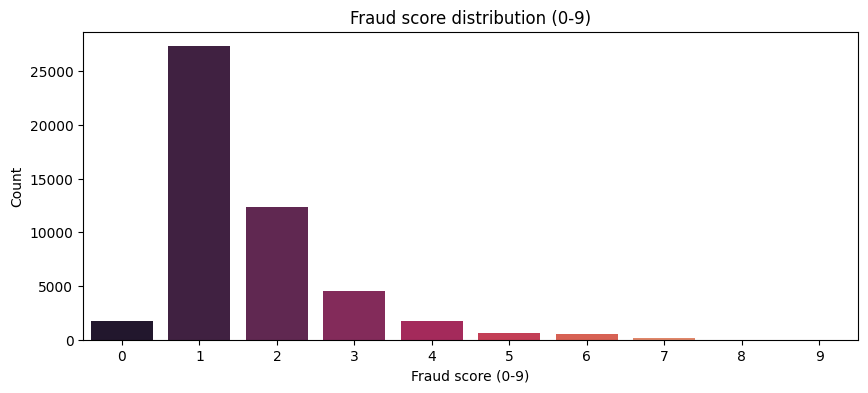

Done visualizing fraud_score.


C:\Users\hp\AppData\Local\Temp\ipykernel_14424\1138147854.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered.drop(columns=['fraud_score_clipped'], inplace=True)


In [69]:
# Visualize fraud_score distribution (0-9) and show examples per score
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Ensure fraud_score exists
if 'fraud_score' not in df_filtered.columns:
    raise KeyError('fraud_score column not found in df_filtered. Run the fraud_score creation cell first.')

# Restrict to scores 0-9 for plotting and reporting
df_filtered['fraud_score_clipped'] = df_filtered['fraud_score'].clip(lower=0, upper=9).astype(int)

# Counts and percentages
counts = df_filtered['fraud_score_clipped'].value_counts().reindex(range(0,10), fill_value=0)
percent = (counts / len(df_filtered) * 100).round(2)

print('Fraud score distribution (0-9):')
for score in range(0,10):
    print(f'  Score {score}: {counts.loc[score]} rows ({percent.loc[score]}%)')

# Barplot (0-9)
plt.figure(figsize=(10,4))
sns.barplot(x=list(counts.index), y=counts.values, palette='rocket')
plt.xlabel('Fraud score (0-9)')
plt.ylabel('Count')
plt.title('Fraud score distribution (0-9)')
plt.xticks(range(0,10))
plt.show()

# Clean up helper column to avoid accidental persistence beyond this cell's intent
df_filtered.drop(columns=['fraud_score_clipped'], inplace=True)
print('Done visualizing fraud_score.')

In [72]:
# Show cars with the highest fraud_score and top suspicious listings
# Recompute fraud_score if it's missing (use same anomaly columns as earlier)
if 'fraud_score' not in df_filtered.columns:
    anomaly_cols = [
        'year_anomaly', 'mileage_anomaly', 'power_anomaly', 'repair_anomaly',
        'duplicate_anomaly', 'fuelType_anomaly', 'gearbox_anomaly', 'vehicleType_anomaly', 'brand_anomaly'
    ]
    df_filtered['fraud_score'] = df_filtered[anomaly_cols].sum(axis=1)

if df_filtered.empty:
    print('df_filtered is empty — no rows to inspect.')
else:
    max_score = int(df_filtered['fraud_score'].max())
    top_rows = df_filtered[df_filtered['fraud_score'] == max_score].copy()
    print(f'Max fraud_score = {max_score}; rows with this score: {len(top_rows)}')
    # Show relevant columns for inspection (adjust as needed)
    cols = [c for c in ['fraud_score','brand','model','yearOfRegistration','price','odometer','car_age'] if c in df_filtered.columns]
    from IPython.display import display
    if len(top_rows) > 0:
        print('Examples of listings with the highest fraud_score:')
        display(top_rows[cols].sort_values(by=['price'], ascending=False).head(50))
    # Also show the top 20 listings sorted by fraud_score then price for context
    print('Top 20 listings by fraud_score (then price desc):')
    display(df_filtered.sort_values(by=['fraud_score','price'], ascending=[False,False]).head(20))

Max fraud_score = 7; rows with this score: 139
Examples of listings with the highest fraud_score:


,fraud_score,brand,model,yearOfRegistration,price,odometer,car_age
7653,7,renault,twingo,2017,$900,5000.0,8
36366,7,toyota,andere,1985,$900,150000.0,40
2044,7,mercedes_benz,c_klasse,2000,$900,100000.0,25
21225,7,volkswagen,Unknown,1985,"$9,999",100000.0,40
41624,7,volkswagen,Unknown,1990,$800,150000.0,35
7855,7,volkswagen,golf,2000,$80,5000.0,25
37052,7,chevrolet,spark,2011,$80,5000.0,14
14042,7,ford,andere,1985,"$8,500",150000.0,40
28372,7,porsche,Unknown,2015,$8,5000.0,10
23829,7,renault,twingo,2017,$650,5000.0,8


Top 20 listings by fraud_score (then price desc):


,dateCrawled,name,seller,offerType,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,odometer,monthOfRegistration,fuelType,brand,notRepairedDamage,dateCreated,nrOfPictures,postalCode,lastSeen,RepairedDamage,year_anomaly,car_age,km_per_year,mileage_anomaly,powerPS_raw,power_anomaly,repair_anomaly,duplicate_anomaly,temporal_anomaly_1,temporal_anomaly_2,ad_duration,temporal_anomaly_3,temporal_anomaly,fuelType_anomaly,gearbox_anomaly,vehicleType_anomaly,brand_anomaly,fraud_score
2044,2016-03-24 10:54:55,3_x_MB_C180_W_202_1.8_L,privat,Angebot,$900,test,unknown,2000,unknown,0,c_klasse,100000.0,0,unknown,mercedes_benz,Unknown,2016-03-24,0,59427,2016-03-27 08:15:19,NaN,0,25,4000.000000,1,0,1,1,1,0,0,3,0,0,1,1,1,0,7
7653,2016-03-19 20:58:24,renault_twingo,privat,Angebot,$900,control,unknown,2017,unknown,0,twingo,5000.0,0,unknown,renault,Unknown,2016-03-19,0,44805,2016-03-22 03:16:29,NaN,0,8,625.000000,1,0,1,1,1,0,0,3,0,0,1,1,1,0,7
36366,2016-03-23 15:06:22,Toyota_MR2_Twin_Cam_16_124Ps,privat,Angebot,$900,control,unknown,1985,unknown,0,andere,150000.0,0,unknown,toyota,Unknown,2016-03-23,0,35708,2016-04-06 14:45:36,NaN,0,40,3750.000000,1,0,1,1,1,0,0,14,0,0,1,1,1,0,7
21225,2016-03-19 15:40:01,Vw_Kaefer_airride__und_t2b_Fensterbus_73,privat,Angebot,"$9,999",control,unknown,1985,unknown,0,Unknown,100000.0,0,unknown,volkswagen,Unknown,2016-03-19,0,8056,2016-03-24 10:15:52,NaN,0,40,2500.000000,1,0,1,1,1,0,0,5,0,0,1,1,1,0,7
41624,2016-03-25 20:48:48,Caddy_14d,privat,Angebot,$800,control,unknown,1990,unknown,0,Unknown,150000.0,0,unknown,volkswagen,Unknown,2016-03-25,0,7749,2016-04-07 03:17:42,NaN,0,35,4285.714286,1,0,1,1,1,0,0,13,0,0,1,1,1,0,7
7855,2016-03-09 22:53:57,Original_VW_Front_Stossstange_Golf__GTI__GTD,privat,Angebot,$80,test,unknown,2000,unknown,0,golf,5000.0,7,unknown,volkswagen,Unknown,2016-03-09,0,52222,2016-03-11 04:44:56,NaN,0,25,200.000000,1,0,1,1,1,0,0,2,0,0,1,1,1,0,7
37052,2016-03-08 12:47:33,4_Sommer_kpl._Raeder_fuer_Chevrolet_Spark_155/...,privat,Angebot,$80,test,unknown,2011,unknown,0,spark,5000.0,0,unknown,chevrolet,Unknown,2016-03-08,0,51427,2016-04-05 12:20:59,NaN,0,14,357.142857,1,0,1,1,1,0,0,28,0,0,1,1,1,0,7
14042,2016-03-12 04:02:18,CAPRI_2_liter,privat,Angebot,"$8,500",test,unknown,1985,unknown,0,andere,150000.0,0,unknown,ford,Unknown,2016-03-12,0,21647,2016-03-12 07:37:41,NaN,0,40,3750.000000,1,0,1,1,1,0,0,0,0,0,1,1,1,0,7
28372,2016-03-17 00:36:58,500_Designer_Pumps_Echt_Leder_Italien_Restpost...,privat,Angebot,$8,test,unknown,2015,unknown,0,Unknown,5000.0,0,unknown,porsche,Unknown,2016-03-16,0,50678,2016-03-17 07:39:14,NaN,0,10,500.000000,1,0,1,1,1,0,0,1,0,0,1,1,1,0,7
23829,2016-03-29 01:53:51,Renault_Twingo,privat,Angebot,$650,control,unknown,2017,unknown,0,twingo,5000.0,0,unknown,renault,Unknown,2016-03-28,0,74523,2016-03-31 00:17:52,NaN,0,8,625.000000,1,0,1,1,1,0,0,3,0,0,1,1,1,0,7


In [73]:
# Label fraudulent listings
# Threshold = 2 (adjustable)
df_filtered['is_fraud'] = df_filtered['fraud_score'].apply(lambda x: 1 if x >= 2 else 0)

C:\Users\hp\AppData\Local\Temp\ipykernel_14424\2697551683.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['is_fraud'] = df_filtered['fraud_score'].apply(lambda x: 1 if x >= 2 else 0)


In [74]:
# 9. Inspect results
# ------------------------------
print("Fraud score distribution:")
print(df_filtered['fraud_score'].value_counts().sort_index())
print("\nNumber of fraudulent listings:", df_filtered['is_fraud'].sum())

print("\nTop 10 suspicious listings:")
display(df_filtered.sort_values(by='fraud_score', ascending=False).head(10))

Fraud score distribution:
fraud_score
0     1756
1    27326
2    12405
3     4546
4     1782
5      672
6      537
7      139
Name: count, dtype: int64

Number of fraudulent listings: 20081

Top 10 suspicious listings:


,dateCrawled,name,seller,offerType,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,odometer,monthOfRegistration,fuelType,brand,notRepairedDamage,dateCreated,nrOfPictures,postalCode,lastSeen,RepairedDamage,year_anomaly,car_age,km_per_year,mileage_anomaly,powerPS_raw,power_anomaly,repair_anomaly,duplicate_anomaly,temporal_anomaly_1,temporal_anomaly_2,ad_duration,temporal_anomaly_3,temporal_anomaly,fuelType_anomaly,gearbox_anomaly,vehicleType_anomaly,brand_anomaly,fraud_score,is_fraud
23699,2016-03-26 13:49:19,Suche_Auto_in_Tausch_gegen_Laptop,privat,Angebot,$0,control,unknown,2000,unknown,0,Unknown,5000.0,0,unknown,sonstige_autos,Unknown,2016-03-26,0,23843,2016-03-26 13:49:19,NaN,0,25,200.000000,1,0,1,1,1,0,0,0,0,0,1,1,1,0,7,1
38576,2016-04-01 13:57:00,Trabant601,privat,Angebot,$150,test,unknown,1985,unknown,0,601,100000.0,0,unknown,trabant,Unknown,2016-04-01,0,96049,2016-04-01 14:46:21,NaN,0,40,2500.000000,1,0,1,1,1,0,0,0,0,0,1,1,1,0,7,1
7855,2016-03-09 22:53:57,Original_VW_Front_Stossstange_Golf__GTI__GTD,privat,Angebot,$80,test,unknown,2000,unknown,0,golf,5000.0,7,unknown,volkswagen,Unknown,2016-03-09,0,52222,2016-03-11 04:44:56,NaN,0,25,200.000000,1,0,1,1,1,0,0,2,0,0,1,1,1,0,7,1
4364,2016-03-23 10:37:39,BMW_Codierung_E46_E39_E60_E38_E87_usw..,privat,Angebot,$40,control,unknown,1995,unknown,0,Unknown,5000.0,0,unknown,bmw,Unknown,2016-03-23,0,75177,2016-03-23 11:43:17,NaN,0,30,166.666667,1,0,1,1,1,0,0,0,0,0,1,1,1,0,7,1
7653,2016-03-19 20:58:24,renault_twingo,privat,Angebot,$900,control,unknown,2017,unknown,0,twingo,5000.0,0,unknown,renault,Unknown,2016-03-19,0,44805,2016-03-22 03:16:29,NaN,0,8,625.000000,1,0,1,1,1,0,0,3,0,0,1,1,1,0,7,1
38299,2016-03-28 22:25:25,Glas_BMW_mit_Wasser,privat,Angebot,"$250,000",test,unknown,2015,unknown,0,x_reihe,5000.0,0,unknown,bmw,Unknown,2016-03-28,0,60489,2016-03-28 22:25:25,NaN,0,10,500.000000,1,0,1,1,1,0,0,0,0,0,1,1,1,0,7,1
38847,2016-03-22 18:56:49,Proline_wheels_pxi_18_zoll_felgen_mit_sommerbe...,privat,Angebot,$0,control,unknown,2000,unknown,0,Unknown,20000.0,0,unknown,bmw,Unknown,2016-03-22,0,40589,2016-03-22 19:39:59,NaN,0,25,800.000000,1,0,1,1,1,0,0,0,0,0,1,1,1,0,7,1
49844,2016-03-26 19:43:51,Fahrzeug_Ankauf!!!!,privat,Angebot,"$22,222",control,unknown,2005,unknown,0,Unknown,5000.0,0,unknown,opel,Unknown,2016-03-26,0,72160,2016-03-26 19:43:51,NaN,0,20,250.000000,1,0,1,1,1,0,0,0,0,0,1,1,1,0,7,1
17919,2016-03-23 17:52:21,VW_Polo_6n1_Tuning,privat,Angebot,$250,control,unknown,2000,unknown,0,polo,5000.0,0,unknown,volkswagen,Unknown,2016-03-23,0,96155,2016-04-05 22:17:57,NaN,0,25,200.000000,1,0,1,1,1,0,0,13,0,0,1,1,1,0,7,1
30716,2016-03-24 21:36:44,Alfa_Romeo_75_1_8_Turbo_Evolotion_evo,privat,Angebot,"$4,999",test,unknown,1990,unknown,0,andere,150000.0,0,unknown,alfa_romeo,Unknown,2016-03-24,0,22303,2016-04-05 18:46:44,NaN,0,35,4285.714286,1,0,1,1,1,0,0,12,0,0,1,1,1,0,7,1


# **Modeling**

**Target and feature selection**

In [75]:
# Target
y = df_filtered['is_fraud']

# Features: numerical + categorical
numerical_features = ['odometer', 'powerPS', 'car_age']
categorical_features = ['brand', 'fuelType', 'gearbox', 'vehicleType']

# Optional: include anomaly flags as features
anomaly_flags = ['year_anomaly','mileage_anomaly','power_anomaly','repair_anomaly',
                 'duplicate_anomaly','fuelType_anomaly','gearbox_anomaly',
                 'vehicleType_anomaly','brand_anomaly']

X = df_filtered[numerical_features + categorical_features + anomaly_flags]

In [76]:
# One-hot encode categorical features
X = pd.get_dummies(X, columns=categorical_features, drop_first=True)

In [ ]:
scaler = StandardScaler()
X[numerical_features] = scaler.fit_transform(X[numerical_features])

In [77]:
# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (39330, 68)
Testing set size: (9833, 68)


**Random forest classifier**

In [78]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Initialize Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,       # number of trees
    max_depth=10,           # limit depth to prevent overfitting
    random_state=42,
    class_weight='balanced' # handle class imbalance
)


In [79]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       random_state=42)

In [80]:
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:,1]  # probability of fraud


In [81]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_proba)
print("ROC-AUC Score:", roc_auc)


Confusion Matrix:
 [[5776   41]
 [   0 4016]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00      5817
           1       0.99      1.00      0.99      4016

    accuracy                           1.00      9833
   macro avg       0.99      1.00      1.00      9833
weighted avg       1.00      1.00      1.00      9833

ROC-AUC Score: 0.999997260399694


In [82]:
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, class_weight='balanced')
rf_model.fit(X, y)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       random_state=42)

In [89]:
# Recreate scaler (ensure it's fitted on the same data used for training)
scaler = StandardScaler()
X_temp = df_filtered[numerical_features + categorical_features + anomaly_flags].copy()
X_temp = pd.get_dummies(X_temp, columns=categorical_features, drop_first=True)
X_temp[numerical_features] = scaler.fit_transform(X_temp[numerical_features])

# Define folder path
folder_path = r"D:\mmm\mmm\2025-2026 5SAE1\AI\projet"

# Ensure the folder exists
os.makedirs(folder_path, exist_ok=True)

# Paths for model and scaler
model_path = os.path.join(folder_path, "rf_fraud_model.pkl")
scaler_path = os.path.join(folder_path, "scaler.pkl")

# Save model
with open(model_path, 'wb') as f:
    pickle.dump(rf_model, f)

# Save scaler
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)

print(f"✓ Model saved at: {model_path}")
print(f"✓ Scaler saved at: {scaler_path}")

# Verify files were created and are not empty
import os
model_size = os.path.getsize(model_path)
scaler_size = os.path.getsize(scaler_path)
print(f"✓ Model file size: {model_size:,} bytes")
print(f"✓ Scaler file size: {scaler_size:,} bytes")

# Test loading
with open(scaler_path, 'rb') as f:
    test_scaler = pickle.load(f)
print("✓ Scaler loads successfully!")
print(f"✓ Scaler fitted on {len(numerical_features)} features: {numerical_features}")

✓ Model saved at: D:\mmm\mmm\2025-2026 5SAE1\AI\projet\rf_fraud_model.pkl
✓ Scaler saved at: D:\mmm\mmm\2025-2026 5SAE1\AI\projet\scaler.pkl
✓ Model file size: 5,221,950 bytes
✓ Scaler file size: 640 bytes
✓ Scaler loads successfully!
✓ Scaler fitted on 3 features: ['odometer', 'powerPS', 'car_age']
